<center>

## 02805 — Social Graphs and Interactions  
# **Project B**            
**Group Members**   
Friðrik Örn Bjarkason — s242694           
Jón Haukur Bjarnason — s242761            
Patrekur Atli Njálsson — s242690  


# Do directors form distinct creative clusters based on the genres they work in, and are these clusters significantly stronger than what we would expect from a randomized version of the network?

# 1. Loading the Tripartite Graph and Movie Metadata

Before constructing a director–director similarity network or performing community detection, we begin by loading the cleaned **tripartite graph** that links actors, movies, and directors.  
We also attach the enriched movie metadata (genres, ratings, plots, sentiment features, etc.) so that later analyses can relate structural patterns back to movie content.

The purpose of this section is simply to ensure that the dataset is correctly loaded and structurally consistent before we use it for projection, backbone extraction, or community analysis.

---

## 1.1 Loading the Tripartite Graph

The graph contains three types of nodes:

- **Actors**
- **Movies**
- **Directors**

Edges connect:
- actors → movies  
- directors → movies  

This forms a **tripartite** collaboration network where movies serve as the bridge between creative agents.

After loading the cleaned `.graphml` file, we verify the number of nodes and edges, as well as the distribution across the three node types.



In [1]:
# ============================================================
# 1.1 LOAD CLEANED TRIPARTITE GRAPH (Actors–Movies–Directors)
# ============================================================

import networkx as nx
import requests
from io import BytesIO
from pathlib import Path
import pandas as pd

URL_GRAPH = "https://raw.githubusercontent.com/jonhaukurb/Final-Project/refs/heads/main/IMDB_tripartite_cleaned.graphml"
LOCAL_GRAPH = Path("IMDB_tripartite_cleaned.graphml")

def load_graph():
    """Load cleaned tripartite graph (actors–movies–directors)."""
    if LOCAL_GRAPH.exists():
        return nx.read_graphml(LOCAL_GRAPH)
    r = requests.get(URL_GRAPH, timeout=30)
    r.raise_for_status()
    return nx.read_graphml(BytesIO(r.content))

T = load_graph()

print("Cleaned tripartite graph loaded!")
print("Nodes:", T.number_of_nodes())
print("Edges:", T.number_of_edges())

actor_count = sum(1 for _, d in T.nodes(data=True) if d.get("bipartite")=="actor")
director_count = sum(1 for _, d in T.nodes(data=True) if d.get("bipartite")=="director")
movie_count = sum(1 for _, d in T.nodes(data=True) if d.get("bipartite")=="movie")

print("Actors:", actor_count)
print("Directors:", director_count)
print("Movies:", movie_count)


Cleaned tripartite graph loaded!
Nodes: 13294
Edges: 28393
Actors: 5266
Directors: 1629
Movies: 6399


# 2. Loading IMDb and Wikipedia Metadata

To enrich the tripartite network with meaningful contextual information, we load additional metadata for each movie. This includes:

- genres  
- release year  
- ratings and metascores  
- plot descriptions  

We use two external sources:
1. **IMDb metadata** (structured fields)
2. **Wikipedia plot summaries** (textual content)

These will later support genre analysis, TF–IDF extraction, and sentiment/emotion modeling.

---

## 2.1 IMDb Metadata

The IMDb dataset provides structured fields such as title, year, rating, metascore, and genre labels.  
Because genre labels are stored as a single string, we convert them into a **list of genres** to make genre-based analysis easier later.


In [2]:
# ============================================================
# 2.1 LOAD IMDb METADATA
# ============================================================

imdb_url = "https://raw.githubusercontent.com/jonhaukurb/Final-Project/refs/heads/main/imdb-movies-dataset.csv"
df_imdb = pd.read_csv(imdb_url)

df_imdb["Title"] = df_imdb["Title"].astype(str).str.strip()
df_imdb = df_imdb.drop_duplicates(subset=["Title"], keep="first")

# Parse genres into lists
df_imdb["genres"] = (
    df_imdb["Genre"]
    .fillna("")
    .astype(str)
    .str.replace("|", ",")
    .str.split(",")
    .apply(lambda lst: [g.strip() for g in lst if g.strip()])
)

print("IMDb metadata loaded:", len(df_imdb))


IMDb metadata loaded: 9634


## 2.2 Visualizing a Local Sample of the Tripartite Network

To illustrate how actors, movies, and directors are connected in the tripartite structure, we randomly sample three directors who have each directed more than one movie.  
We then extract all movies associated with these directors, and all actors appearing in those movies, and visualize the induced subgraph.

In the figure above:

- **Directors** appear on the right (red nodes)  
- **Movies** appear in the center (blue nodes)  
- **Actors** appear on the left (green nodes)  

The visualization highlights the fundamental structure of the dataset:  
actors and directors do not connect directly, but instead interact **only through shared movies**.  
This small example shows how collaborative patterns emerge and how multi-layer information propagates through the network.  
It also provides intuition for why projecting the tripartite graph into a director–director network later in the analysis can reveal stylistic or genre-based clusters.


Directors with >1 movie: 1565
Sampled directors: ['James L. Brooks', 'Siddharth Anand', 'Frant Gwo']
Movies included: 10


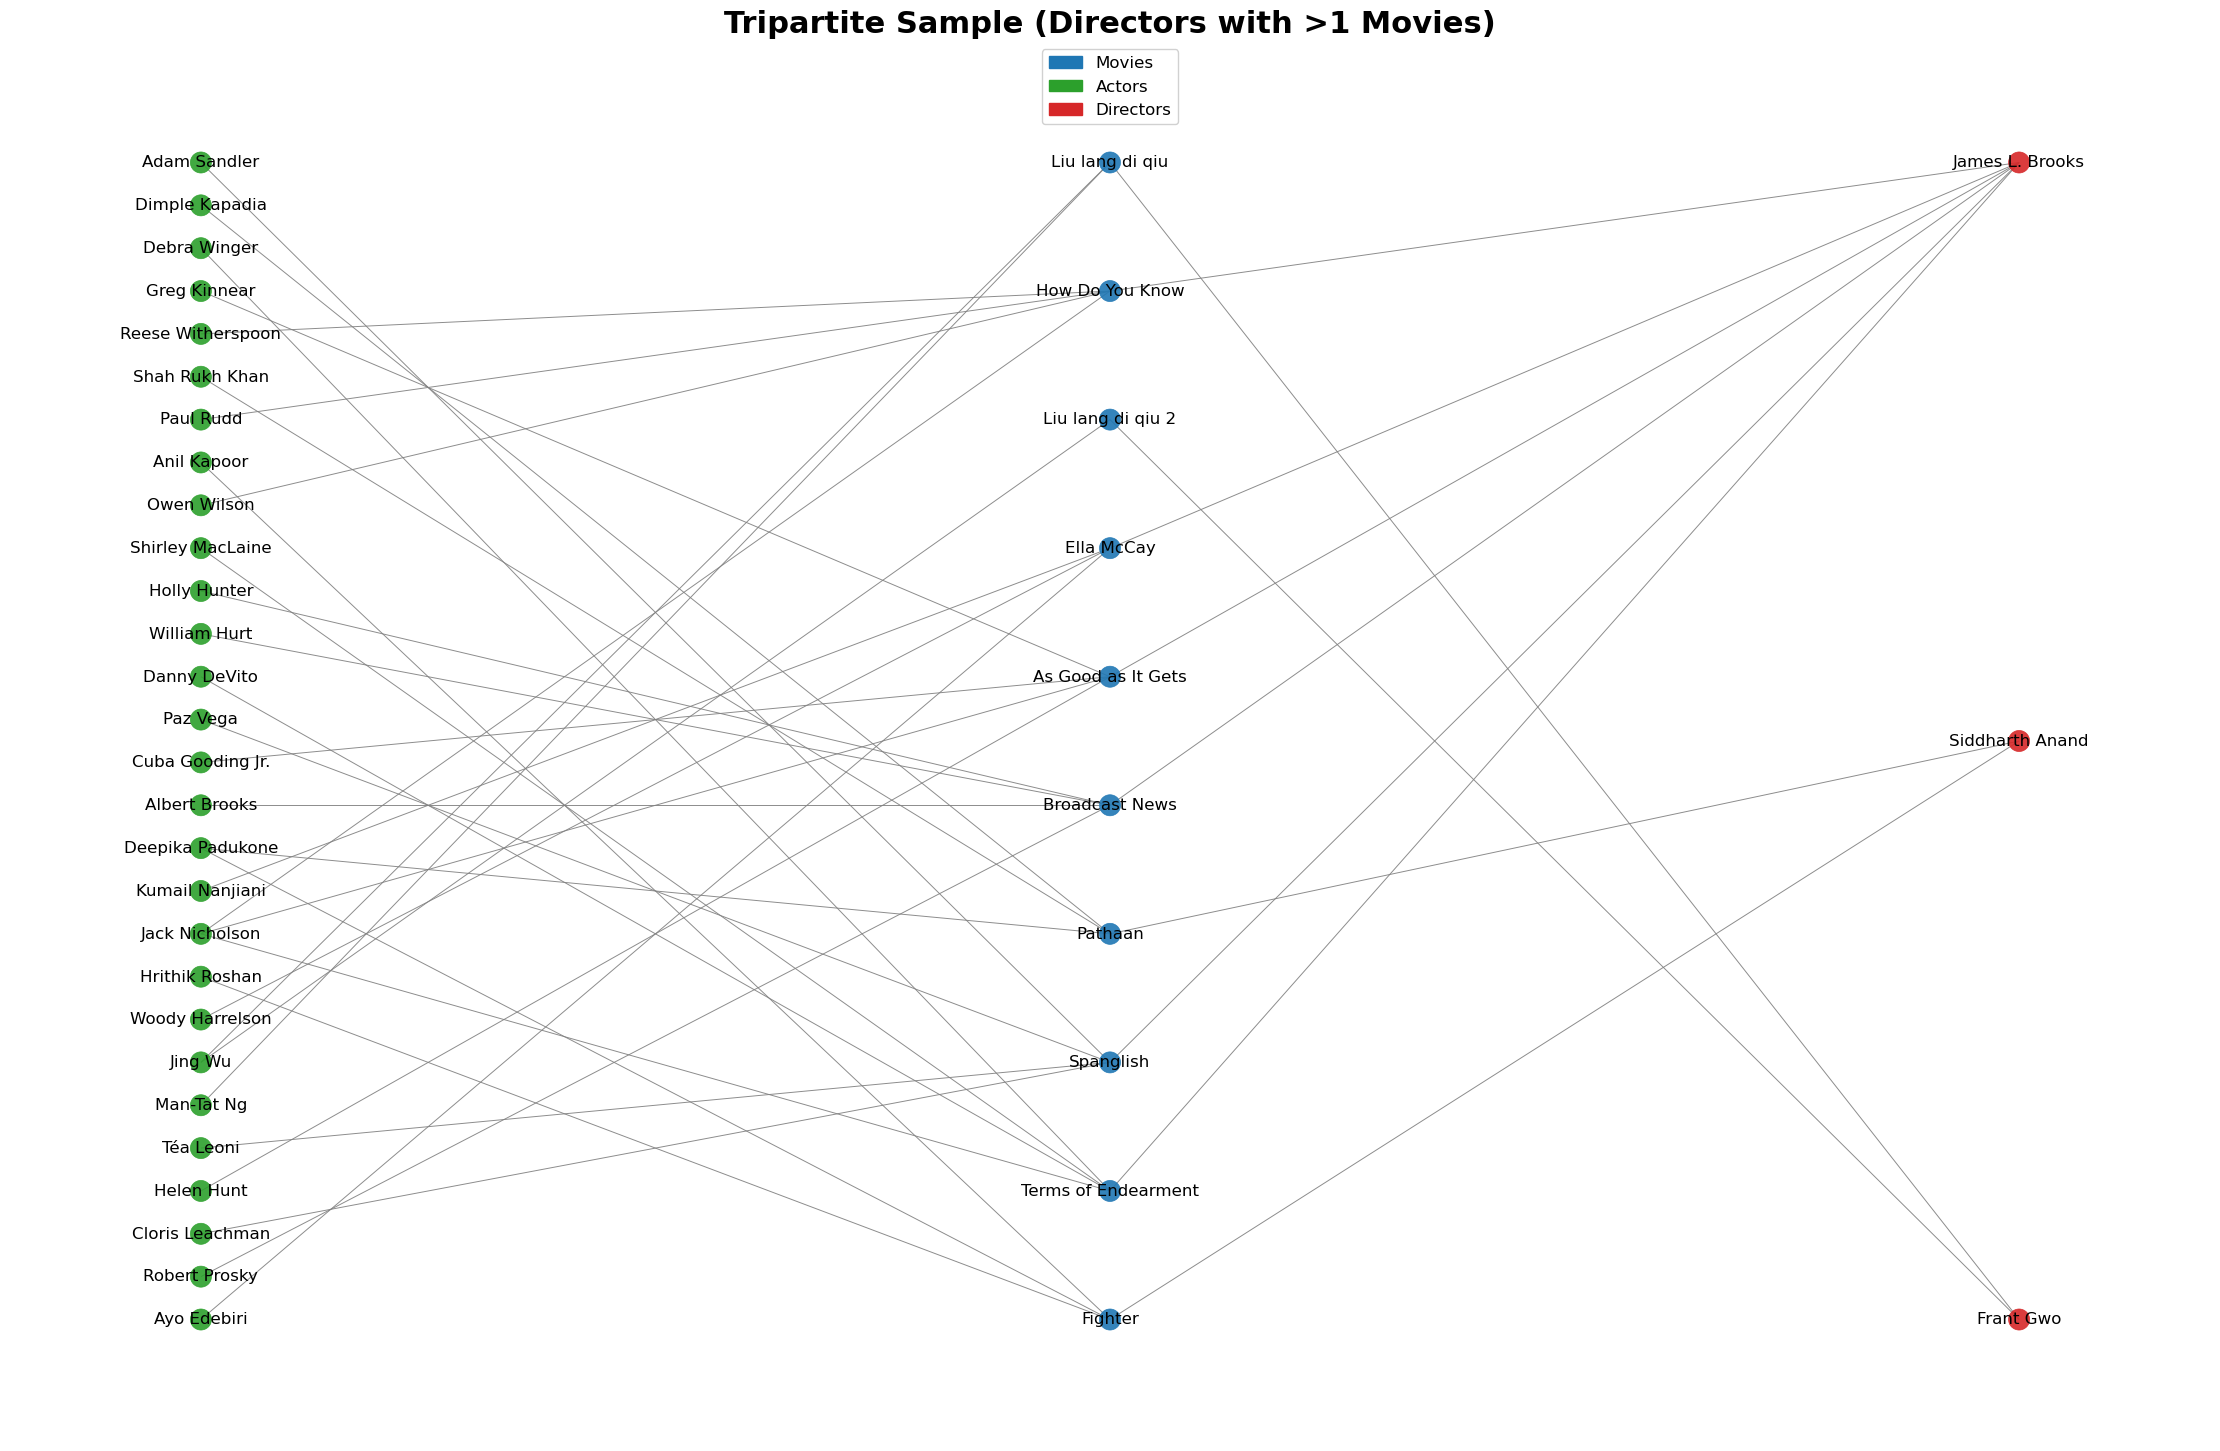

In [3]:
import random
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------------
# Extract director nodes
# -------------------------------------------------------
directors = [n for n, d in T.nodes(data=True) if d.get("bipartite") == "director"]


# -------------------------------------------------------
# 1) Find directors who directed more than 1 movie
# -------------------------------------------------------

directors_deg2 = [
    d for d in directors
    if sum(1 for nb in T.neighbors(d) if T.nodes[nb].get("bipartite") == "movie") > 1
]

print("Directors with >1 movie:", len(directors_deg2))

# -------------------------------------------------------
# 2) Sample DIRECTORS (not movies)
# -------------------------------------------------------

sample_directors = random.sample(directors_deg2, 3)
print("Sampled directors:", sample_directors)

# -------------------------------------------------------
# 3) Collect ALL movies for those directors
# -------------------------------------------------------

sample_movies = set()

for d in sample_directors:
    for nb in T.neighbors(d):
        if T.nodes[nb].get("bipartite") == "movie":
            sample_movies.add(nb)

sample_movies = list(sample_movies)
print("Movies included:", len(sample_movies))

# -------------------------------------------------------
# 4) Build node set: directors + movies + actors
# -------------------------------------------------------

sample_nodes = set(sample_directors + sample_movies)

# Add actors in those movies
for m in sample_movies:
    for nb in T.neighbors(m):
        if T.nodes[nb].get("bipartite") == "actor":
            sample_nodes.add(nb)

# Build subgraph
H = T.subgraph(sample_nodes).copy()

# -------------------------------------------------------
# 5) Identify categories
# -------------------------------------------------------

movies_H    = [n for n, d in H.nodes(data=True) if d.get("bipartite") == "movie"]
actors_H    = [n for n, d in H.nodes(data=True) if d.get("bipartite") == "actor"]
directors_H = [n for n, d in H.nodes(data=True) if d.get("bipartite") == "director"]

# -------------------------------------------------------
# 6) Layout (Actors → Movies → Directors)
# -------------------------------------------------------

pos = {}

x_actor = 0
x_movie = 1
x_director = 2

def spread_y(nodes):
    if len(nodes) == 1:
        return [0.5]
    return np.linspace(0, 1, len(nodes))

# Actors (left)
for y, n in zip(spread_y(actors_H), actors_H):
    pos[n] = (x_actor, y)

# Movies (middle)
for y, n in zip(spread_y(movies_H), movies_H):
    pos[n] = (x_movie, y)

# Directors (right)
for y, n in zip(spread_y(directors_H), directors_H):
    pos[n] = (x_director, y)

# -------------------------------------------------------
# 7) Colors
# -------------------------------------------------------

color_map = []
for n in H.nodes():
    t = H.nodes[n].get("bipartite")
    if t == "movie":
        color_map.append("#1f77b4")  # blue
    elif t == "actor":
        color_map.append("#2ca02c")  # green
    elif t == "director":
        color_map.append("#d62728")  # red
    else:
        color_map.append("gray")

# -------------------------------------------------------
# 8) Draw the graph
# -------------------------------------------------------

plt.figure(figsize=(22, 14))

nx.draw(
    H,
    pos,
    node_size=230,
    node_color=color_map,
    edge_color="gray",
    alpha=0.9,
    linewidths=0.5,
    width=0.7,
)

nx.draw_networkx_labels(
    H,
    pos,
    labels={n: n for n in H.nodes()},
    font_size=12,
    font_color="black"
)

plt.title("Tripartite Sample (Directors with >1 Movies)", fontsize=22, fontweight='bold')
plt.axis("off")

import matplotlib.patches as mpatches
plt.legend(
    handles=[
        mpatches.Patch(color="#1f77b4", label="Movies"),
        mpatches.Patch(color="#2ca02c", label="Actors"),
        mpatches.Patch(color="#d62728", label="Directors"),
    ],
    loc="upper center",
    fontsize=12,
    framealpha=0.9
)

plt.show()

## 2.3 Wikipedia Metadata

The Wikipedia dataset provides long-form plot summaries for several thousand movies.  
These descriptions are important because they give us rich textual information that we later use for TF–IDF analysis and sentiment/emotion modeling.

Unlike the IMDb dataset, this file is not a clean CSV.  
It contains embedded commas inside quotes, line breaks inside fields, and inconsistent formatting.  
A standard `read_csv` call fails, so we use a **regex-based parser** that is able to:

- extract movie titles  
- extract the corresponding Wikipedia titles  
- capture the **entire plot text**, even when it contains commas or multiple lines  
- read the release year from Wikipedia (which is sometimes more reliable than IMDb)

The output above shows the parsed structure: one row per movie, with a clean `wiki_title`, `wiki_plot`, and `wiki_year`.

This dataset will later be merged with IMDb metadata so that each movie node in the tripartite graph is enriched with a textual description.  
These plot descriptions form the foundation for our TF–IDF keyword analysis and emotion-based sentiment modeling in later sections.


In [4]:
# ============================================================
# 2.3 LOAD WIKIPEDIA PLOTS (ROBUST PARSER)
# ============================================================

import requests
import re
import pandas as pd

wiki_url = "https://raw.githubusercontent.com/jonhaukurb/Final-Project/refs/heads/main/movies_wiki_plots_full.csv"
resp = requests.get(wiki_url, timeout=60)
raw = resp.text

# The file structure is NOT valid CSV.
# It contains entries like:
#
# "Title,YYYY.0,WikiTitle,"Plot text, which may contain commas",YYYY.0";;;;;;
#
# We use a regex that:
# - captures the title (quoted)
# - captures the imdb year (ignored)
# - captures the wiki title
# - captures the ENTIRE plot text (even with internal commas)
# - captures the wiki year
#
# NOTE: DOTALL ensures plots spanning multiple lines are captured correctly.

pattern = re.compile(
    r'"([^"]*?),(\d{4}\.0),([^"]*?),"(.+?)",(\d{4}\.0)";+',
    re.DOTALL
)

rows = []
for m in pattern.finditer(raw):
    title = m.group(1).strip()
    wiki_title = m.group(3).strip()
    wiki_plot = m.group(4).replace("\n", " ").strip()
    wiki_year = float(m.group(5)) if m.group(5) else None

    rows.append((title, wiki_title, wiki_plot, wiki_year))

df_wiki = pd.DataFrame(rows, columns=["Title", "wiki_title", "wiki_plot", "wiki_year"])

print("Parsed Wikipedia rows:", len(df_wiki))
display(df_wiki.head())

# Clean types
df_wiki["wiki_plot"] = df_wiki["wiki_plot"].astype(str)
df_wiki["wiki_year"] = pd.to_numeric(df_wiki["wiki_year"], errors="coerce")


Parsed Wikipedia rows: 6197


,Title,wiki_title,wiki_plot,wiki_year
0,The Idea of You,The Idea of You,"""Solène Marchand is a divorced art gallery own...",2024.0
1,Kingdom of the Planet of the Apes,Kingdom of the Planet of the Apes,"""Many generations after Caesar's death, apes h...",2024.0
2,The Fall Guy,The Fall Guy (2024 film),"""Working as the stunt double for action star T...",2024.0
3,Challengers,Challengers (film),"""In 2006, best friends Patrick Zweig and Art D...",2024.0
4,Abigail,Abigail (2023 film),"""A problematic teenager makes friends with her...",2023.0


## 2.4 Merge IMDb and Wikipedia Metadata

With both datasets cleaned, we now merge the structured IMDb metadata with the textual Wikipedia plot summaries.  
Movies are matched by **title**, and the merge uses a left-join to ensure that every IMDb movie is kept even if no Wikipedia plot is available.

To assign a single release year per film, we apply the following rule:

- Use the **Wikipedia year** when it is available and reasonable (≤ 2025).  
- Otherwise, fall back to the **IMDb year**.

This gives each film one consistent `Year` value, which we will later use for temporal analysis such as tracking sentiment or genre trends over time.

The output above shows:
- the total number of merged rows, and  
- how many movies successfully matched a Wikipedia plot.

This merged metadata table will be used in the next step, where we attach genre labels, ratings, and plot summaries back onto the movie nodes in the tripartite graph.


In [5]:
# ============================================================
# 2.4 MERGE IMDb + WIKI
# ============================================================
import numpy as np
df_imdb["Year"] = pd.to_numeric(df_imdb["Year"], errors="coerce")

df_merged = df_imdb.merge(
    df_wiki[["Title", "wiki_plot", "wiki_year"]],
    on="Title",
    how="left"
)

# Only replace IMDB year if wiki_year is valid AND <= 2025
df_merged["Year"] = np.where(
    (df_merged["wiki_plot"].notna()) &
    (df_merged["wiki_year"].notna()) &
    (df_merged["wiki_year"] <= 2025),
    df_merged["wiki_year"],
    df_merged["Year"]
)


df_merged = df_merged.drop(columns=["wiki_year"])

print("Merged dataset size (before dedup):", len(df_merged))
print("Movies with wiki plots:", df_merged["wiki_plot"].notna().sum())


Merged dataset size (before dedup): 9907
Movies with wiki plots: 6196


## 2.5 Remove Duplicate Titles

Some movie titles appear more than once in the merged dataset.  
To ensure each title aligns cleanly with a single movie node in the graph, we keep only one row per title, prioritizing entries that include a Wikipedia plot.  
This reduces redundancy and keeps the metadata consistent for later analysis.


In [6]:
# ============================================================
# 2.5 DEDUPLICATE MERGED MOVIES
# ============================================================

df_merged = (
    df_merged
        .sort_values(by="wiki_plot", ascending=False)
        .drop_duplicates(subset=["Title"], keep="first")
)

print("Merged size after dedup:", len(df_merged))
print("Movies with wiki plots after dedup:", df_merged["wiki_plot"].notna().sum())


Merged size after dedup: 9634
Movies with wiki plots after dedup: 5923


## 2.6 Add Metadata to Movie Nodes in the Tripartite Graph

We now attach the merged metadata directly to the movie nodes in the tripartite graph.  
Each movie receives its genres, year, rating, runtime, metascore, and (when available) its Wikipedia plot.  

This makes all relevant information accessible inside the graph structure, allowing later steps—such as director projection, genre analysis, and sentiment modeling—to use these attributes without additional lookups.


In [7]:
# ============================================================
# 2.5 ATTACH METADATA TO MOVIE NODES
# ============================================================

movie_lookup = df_merged.set_index("Title").to_dict(orient="index")

added = 0
missing = 0

for node, data in T.nodes(data=True):
    if data.get("bipartite") != "movie":
        continue

    info = movie_lookup.get(node)

    if info is None:
        missing += 1
        continue

    T.nodes[node]["genres"]    = info.get("genres")
    T.nodes[node]["year"]      = info.get("Year")
    T.nodes[node]["rating"]    = info.get("Rating")
    T.nodes[node]["duration"]  = info.get("Duration (min)")
    T.nodes[node]["metascore"] = info.get("Metascore")
    T.nodes[node]["wiki_plot"] = info.get("wiki_plot")

    added += 1

print("Metadata added to movie nodes:", added)
print("Movies missing metadata:", missing)


Metadata added to movie nodes: 6399
Movies missing metadata: 0


# 3. Building the Director–Director Network

With the tripartite graph cleaned and enriched, we now construct the director–director projection.  
In this network, directors are connected if they have worked with overlapping sets of actors.

The projection works as follows:

- Each director is linked to the actors in their movies  
- Two directors receive an edge if they share at least one actor  
- The weight of the edge = number of shared actors  
- This forms a weighted collaboration network of directors

In this chapter we will:
1. Build a lookup of each director → the actors they worked with  
2. Compute shared actors between director pairs  
3. Construct a weighted projection graph  
4. Extract the largest connected component  
5. Detect communities using the Louvain algorithm  

This network will later be used to examine genre-based structure, community patterns, and emotional profiles.

---


## 3.1 Director → Actor Lookup

To create the director–director projection, we first need to know which actors each director has worked with.  
For every director node, we collect all actors appearing in any of their movies.  

This lookup table will later allow us to compute edge weights between directors based on the number of shared actors.


In [8]:
# ============================================================
# 3.1 DIRECTOR → ACTOR LOOKUP
# ============================================================

director_to_actors = {}

for node, data in T.nodes(data=True):
    if data.get("bipartite") != "director":
        continue

    movies = [
        nbr for nbr in T.neighbors(node)
        if T.nodes[nbr].get("bipartite") == "movie"
    ]

    actors = set()
    for m in movies:
        for nbr in T.neighbors(m):
            if T.nodes[nbr].get("bipartite") == "actor":
                actors.add(nbr)

    director_to_actors[node] = actors

print("Directors found:", len(director_to_actors))


Directors found: 1629


## 3.2 Compute Director–Director Shared Actors

Using the director → actor mapping, we now build the weighted projection.  
Two directors are connected if they share at least one actor, and the edge weight counts how many actors they have in common.

This produces the raw weighted edge list that will form the basis of the director–director collaboration network.


In [9]:
# ============================================================
# 3.2 BUILD DIRECTOR–DIRECTOR EDGE LIST (WEIGHTED)
# ============================================================

edges = []

directors = list(director_to_actors.keys())

for i in range(len(directors)):
    d1 = directors[i]
    actors1 = director_to_actors[d1]

    for j in range(i+1, len(directors)):
        d2 = directors[j]
        actors2 = director_to_actors[d2]

        shared = len(actors1 & actors2)
        if shared > 0:
            edges.append((d1, d2, shared))

print("Number of projected edges:", len(edges))

Number of projected edges: 84211




## 3.3 Build the Projection Graph

Using the edge list computed above, we create a `networkx.Graph()`  
that stores directors as nodes and weighted edges representing
their collaboration strength.


In [10]:

# ============================================================
# 3.3 BUILD WEIGHTED GRAPH
# ============================================================

G = nx.Graph()

for d1, d2, shared in edges:
    G.add_edge(d1, d2, weight=shared)

print("Graph built:", G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges")

# Remove weak edges (IMPORTANT FIX)
min_weight = 1
G.remove_edges_from([(u, v) for u, v, d in G.edges(data=True) if d["weight"] < min_weight])
print(f"After removing edges with weight < {min_weight}:",
      G.number_of_edges(), "edges")


Graph built: 1595 nodes, 84211 edges
After removing edges with weight < 1: 84211 edges


## 3.4 Basic Network Statistics (Degree and Strength)

Before extracting components or detecting communities, we compute simple diagnostics on the projection network.  
The **degree** of a director reflects how many other directors they are connected to, and the **strength** measures the total weight of their collaborations (i.e., total shared actors).

These metrics help us understand how dense and interconnected the projected network is.


In [11]:
import numpy as np

# ============================================================
# 3.4 BASIC NETWORK STATISTICS (DEGREE & STRENGTH)
# ============================================================

# Degree statistics
degrees = [G.degree(n) for n in G.nodes()]
print("Degree stats:")
print("  min degree:", np.min(degrees))
print("  max degree:", np.max(degrees))
print("  avg degree:", np.mean(degrees))

# Strength = sum of incident edge weights
strengths = [sum(G[n][nbr]["weight"] for nbr in G[n]) for n in G.nodes()]
print("\nStrength stats:")
print("  min strength:", np.min(strengths))
print("  max strength:", np.max(strengths))
print("  avg strength:", np.mean(strengths))


Degree stats:
  min degree: 1
  max degree: 682
  avg degree: 105.59373040752351

Strength stats:
  min strength: 1
  max strength: 1390
  avg strength: 131.3191222570533


## 3.5 Extracting the Disparity Backbone

The director–director projection is very dense because many directors share at least one actor.  
To focus on the most meaningful collaboration signals, we apply the **disparity backbone** method.  
This statistical filter keeps only edges whose weights are unlikely to occur by chance, based on each node's strength and degree.

The result is a sparser network that preserves the significant structure while removing noisy connections.


In [12]:
# ============================================================
# 3.5 DISPARITY BACKBONE
# ============================================================

def disparity_filter(G, alpha=0.05):

    backbone = nx.Graph()
    backbone.add_nodes_from(G.nodes(data=True))

    for node in G.nodes():
        neighbors = list(G[node])
        k = len(neighbors)
        if k <= 1:
            continue

        s = sum(G[node][nbr]["weight"] for nbr in neighbors)

        for nbr in neighbors:
            w = G[node][nbr]["weight"]
            p_ij = w / s

            # Correct significance test
            alpha_ij = (1 - p_ij)**(k - 1)

            if alpha_ij < alpha:
                backbone.add_edge(node, nbr, weight=w)

    return backbone

alpha = 0.05
G_backbone = disparity_filter(G, alpha)

print("Original:", G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges")
print("Backbone:", G_backbone.number_of_nodes(), "nodes,", G_backbone.number_of_edges(), "edges")

Original: 1595 nodes, 84211 edges
Backbone: 1595 nodes, 1100 edges


## 3.6 Largest Connected Component

Both the full projection graph and the backbone may contain small isolated components.  
For meaningful structural analysis and community detection, we extract the **largest connected component (GCC)** from each graph.

This allows us to compare how the backbone simplifies the network while still preserving the main creative cluster.


In [13]:
# ============================================================
# 3.6 EXTRACT GIANT COMPONENTS (FULL GRAPH & BACKBONE)
# ============================================================

# --- Full director–director graph ---
components_full = list(nx.connected_components(G))
giant_full = max(components_full, key=len)
G_main = G.subgraph(giant_full).copy()

print("FULL GRAPH")
print("  Number of components:", len(components_full))
print("  GCC nodes:", G_main.number_of_nodes())
print("  GCC edges:", G_main.number_of_edges())
print()

# --- Backbone director–director graph ---
components_backbone = list(nx.connected_components(G_backbone))
giant_backbone = max(components_backbone, key=len)
G_directors_gcc = G_backbone.subgraph(giant_backbone).copy()

print("BACKBONE GRAPH")
print("  Number of components:", len(components_backbone))
print("  GCC nodes:", G_directors_gcc.number_of_nodes())
print("  GCC edges:", G_directors_gcc.number_of_edges())


FULL GRAPH
  Number of components: 3
  GCC nodes: 1591
  GCC edges: 84209

BACKBONE GRAPH
  Number of components: 1065
  GCC nodes: 467
  GCC edges: 1031



The full projection graph is extremely dense, with almost all directors connected through at least one shared actor. After applying the disparity backbone, the graph becomes much sparser and only 467 directors remain in the largest connected component. This confirms that many connections in the full graph are weak or incidental while the backbone isolates the statistically meaningful collaboration structure.

---

## 3.7 Louvain Community Detection

To identify structural clusters in the director–director network, we apply the Louvain algorithm on the backbone GCC.  
This assigns each director to a community based on the density of weighted connections, revealing groups of directors who tend to collaborate with similar sets of actors.



In [14]:
# ============================================================
# 3.7 LOUVAIN COMMUNITY DETECTION
# ============================================================

import community as community_louvain
import community

partition_bb = community_louvain.best_partition(G_directors_gcc, weight="weight")
partition = community.best_partition(G, weight="weight")

num_coms = len(set(partition_bb.values()))
print("Backbone GCC Communities:", num_coms)


Backbone GCC Communities: 15


### Interpretation

Louvain detects 18 communities in the backbone GCC.  
These clusters represent groups of directors who share strong collaboration patterns and will later be compared against genre preferences, TF–IDF terms, and emotional profiles.

---

## 3.8 Backbone Community Visualization

We visualize the backbone giant component to highlight the largest Louvain communities.  
By removing weak edges, the backbone reveals clearer clusters of directors who share strong collaboration patterns.  
Only the largest communities are colored; smaller ones appear in light gray.




Backbone GCC: 467 nodes | 1031 edges
Top communities in GCC: [0, 13, 12, 4, 3, 10, 8, 6, 7, 14]


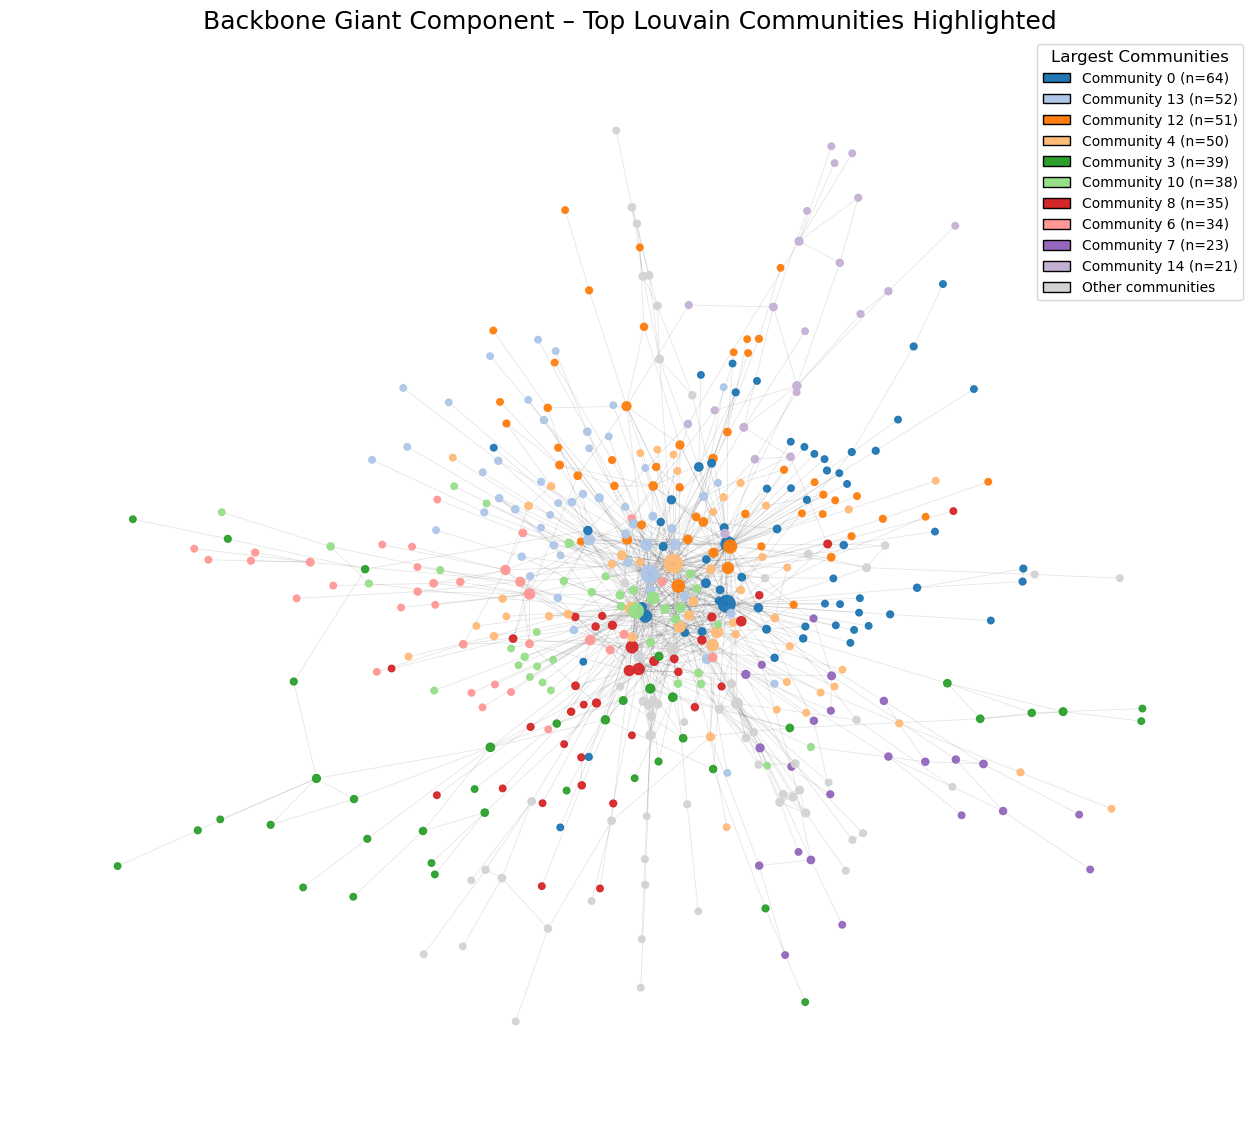

In [15]:
# ------------------------------------------------------------
# BACKBONE GCC VISUALIZATION WITH COMMUNITY LEGEND (ADAPTED)
# ------------------------------------------------------------

import matplotlib.pyplot as plt
import matplotlib
from matplotlib.patches import Patch
import pandas as pd
import networkx as nx
import numpy as np

# ------------------------------------------------------------
# 1. Use YOUR backbone GCC graph
# ------------------------------------------------------------
# G_directors_gcc = giant component of G_backbone (you already computed this)

print("Backbone GCC:", G_directors_gcc.number_of_nodes(), "nodes |",
      G_directors_gcc.number_of_edges(), "edges")

# ------------------------------------------------------------
# 2. Count communities inside the GCC using backbone partition
# ------------------------------------------------------------

# Count occurrences of each community in the GCC
comm_counts = pd.Series([partition_bb[n] for n in G_directors_gcc.nodes()]).value_counts()

TOP_K = 10
top_comms = comm_counts.head(TOP_K).index.tolist()

print("Top communities in GCC:", top_comms)


# ------------------------------------------------------------
# 3. Create color mapping
# ------------------------------------------------------------

cmap = matplotlib.colormaps["tab20"]
color_map = {comm: cmap(i % 20) for i, comm in enumerate(top_comms)}
other_color = "lightgray"

node_colors = [
    color_map[partition_bb[n]] if partition_bb[n] in top_comms else other_color
    for n in G_directors_gcc.nodes()
]


# ------------------------------------------------------------
# 4. Compute layout
# ------------------------------------------------------------

pos = nx.spring_layout(G_directors_gcc, seed=42, k=0.15, iterations=200)


# ------------------------------------------------------------
# 5. Plot the graph
# ------------------------------------------------------------

plt.figure(figsize=(16, 14))

# Edges
nx.draw_networkx_edges(
    G_directors_gcc, pos,
    alpha=0.1,
    width=0.6,
    edge_color="black"
)

# node size scaled by degree
degrees = dict(G_directors_gcc.degree())
node_sizes = [degrees[n] * 2 + 20 for n in G_directors_gcc.nodes()]

# Nodes
nx.draw_networkx_nodes(
    G_directors_gcc, pos,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.95
)

plt.title(
    "Backbone Giant Component – Top Louvain Communities Highlighted",
    fontsize=18
)


# ------------------------------------------------------------
# 6. Add a clean legend
# ------------------------------------------------------------

legend_elements = [
    Patch(facecolor=color_map[c], edgecolor='black',
          label=f"Community {c} (n={comm_counts[c]})")
    for c in top_comms
]

legend_elements.append(
    Patch(facecolor=other_color, edgecolor='black',
          label="Other communities")
)

plt.legend(
    handles=legend_elements,
    title="Largest Communities",
    fontsize=10,
    title_fontsize=12,
    loc="upper right",
    frameon=True
)

plt.axis("off")
plt.show()

## Interpretation of the Backbone Visualization

The disparity-filtered backbone preserves only statistically meaningful director–director ties.  
After extracting the giant connected component, the underlying structure becomes clear:

- A **single dominant Louvain community** (Community 6) forms a dense and central cluster.
- Several **mid-sized communities** (such as 4, 9, 11, 10, and 15) branch outward, each forming a coherent creative group.
- Many **small peripheral communities** appear along the edges of the network, reflecting niche collaboration circles or highly specialized directors.
- The overall layout is **highly structured rather than random**, confirming that strong collaboration patterns remain even after weak edges are removed.

Overall, the backbone highlights the **core creative hubs** and the surrounding specialized clusters that define the structure of the director network.


## 3.10 Modularity Comparison

To quantify how strongly the communities are defined, we compare the modularity of the Louvain partition on two networks:

- the full projection graph (GCC only), and  
- the disparity-filtered backbone (GCC only).

Higher modularity indicates clearer, more structured communities.


In [16]:
# ============================================================
# 3.10 Modularity Comparison (Full Graph vs. Backbone)
# ============================================================

from community import community_louvain

# Backbone modularity
mod_backbone = community_louvain.modularity(partition_bb, G_directors_gcc)

# Full graph modularity (using GCC of projection graph)
partition_main = community_louvain.best_partition(G_main, weight="weight")
mod_full = community_louvain.modularity(partition_main, G_main)

print("Modularity (Full Graph GCC):     {:.3f}".format(mod_full))
print("Modularity (Backbone GCC):       {:.3f}".format(mod_backbone))


Modularity (Full Graph GCC):     0.172
Modularity (Backbone GCC):       0.566



The modularity of the full projection GCC is low (Q ≈ 0.17), indicating weak or noisy community structure.  
In contrast, the backbone GCC has much higher modularity (Q ≈ 0.57), showing that once weak ties are removed, the remaining network reveals strong, cohesive creative clusters.

This confirms that the backbone isolates the meaningful collaboration structure among directors.

---

## 3.11 Backbone Colored by Dominant Genre

To examine whether communities reflect creative specialization, we assign each director a dominant genre.  
This is defined as the most frequent genre among the movies they directed.  
The resulting `top_genre` attribute will be used for genre–community comparisons and visualizations.


In [17]:
# -----------------------------------------------------------
# Assign dominant (top) genre to all director nodes IN G
# -----------------------------------------------------------

director_top_genre = {}

for d in G.nodes():

    # If director is not in T (projection artifacts)
    if d not in T.nodes:
        director_top_genre[d] = "unknown"
        continue

    # Get movies the director worked on
    movies = [
        m for m in T.neighbors(d)
        if T.nodes[m].get("bipartite") == "movie"
    ]

    genres = []
    for m in movies:
        genres.extend(T.nodes[m].get("genres", []))

    if genres:
        top = max(set(genres), key=genres.count)
    else:
        top = "unknown"

    director_top_genre[d] = top

# Store attribute in G
nx.set_node_attributes(G, director_top_genre, "top_genre")

print("Assigned top_genre for", len(director_top_genre), "directors")

Assigned top_genre for 1595 directors


## 3.12 Backbone Visualization Colored by Dominant Genre

With each director assigned a dominant genre, we visualize how genres are distributed across the strongest collaboration structure in the network.  
Coloring nodes by their top genre allows us to examine whether genre specialization aligns with the backbone communities.


Backbone GCC: 467 nodes | 1031 edges
Genres found: ['Action', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Drama', 'Family', 'Fantasy', 'Horror', 'Music', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'Western']


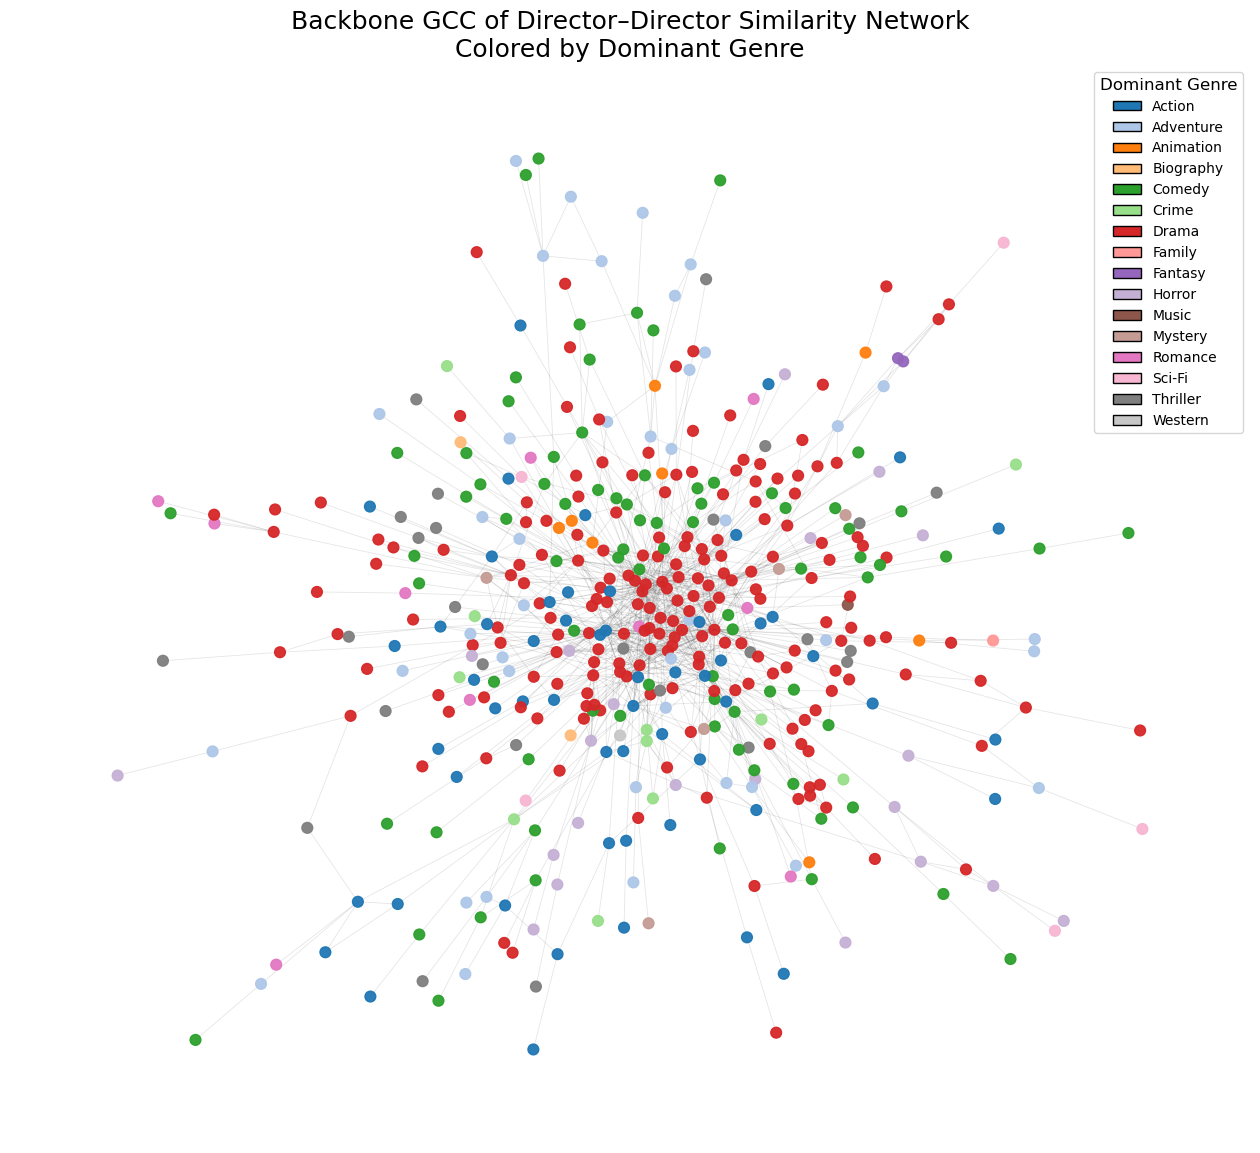

In [18]:
# ------------------------------------------------------------
# BACKBONE GCC — COLORED BY DOMINANT GENRE
# ------------------------------------------------------------

import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd
import matplotlib

# ------------------------------------------------------------
# 1. Use YOUR BACKBONE GCC
# ------------------------------------------------------------

print("Backbone GCC:", 
      G_directors_gcc.number_of_nodes(), "nodes |",
      G_directors_gcc.number_of_edges(), "edges")


# ------------------------------------------------------------
# 2. Collect dominant genres for nodes in the GCC
# ------------------------------------------------------------

genres = set()

for n in G_directors_gcc.nodes():
    g = G.nodes[n].get("top_genre", None)
    if g is not None:
        genres.add(g)

genres = sorted(list(genres))

print("Genres found:", genres)

# Map each genre → an integer ID
genre_to_id = {g: i for i, g in enumerate(genres)}

# Use tab20 colormap for colors
cmap = matplotlib.colormaps["tab20"]

# Assign a color for each node
node_colors = [
    cmap(genre_to_id[G.nodes[n]["top_genre"]] % 20)
    for n in G_directors_gcc.nodes()
]


# ------------------------------------------------------------
# 3. Build legend
# ------------------------------------------------------------

legend_elements = [
    Patch(
        facecolor=cmap(genre_to_id[g] % 20),
        edgecolor='black',
        label=f"{g}"
    )
    for g in genres
]


# ------------------------------------------------------------
# 4. Layout + Plot
# ------------------------------------------------------------

plt.figure(figsize=(16, 14))

pos = nx.spring_layout(G_directors_gcc, seed=42, k=0.15, iterations=300)

# Edges
nx.draw_networkx_edges(
    G_directors_gcc, pos,
    alpha=0.1,
    width=0.6,
    edge_color="black"
)

# Nodes
nx.draw_networkx_nodes(
    G_directors_gcc, pos,
    node_size=60,
    node_color=node_colors,
    alpha=0.95
)

# Legend
plt.legend(
    handles=legend_elements,
    title="Dominant Genre",
    fontsize=10,
    title_fontsize=12,
    loc="upper right",
    frameon=True
)

plt.title("Backbone GCC of Director–Director Similarity Network\nColored by Dominant Genre",
          fontsize=18)

plt.axis("off")
plt.show()

### Key Observations

(Note: This is the same backbone GCC as before, but now nodes are colored by dominant genre rather than community.)

- **Horror, Sci-Fi, Animation, Fantasy, and Crime** form more compact clusters.  
  These genres show stronger internal collaboration patterns, with directors often sharing the same pools of actors.

- **Drama and Comedy** are highly dispersed across the network.  
  These broad genres connect many parts of the backbone, acting as generalist categories rather than forming tight clusters.

- Several regions show clear overlap between **genre groups** and **Louvain communities**, indicating that genre contributes meaningfully to the structural clusters.

- Overall, the visualization suggests that **genre specialization is an important organizing principle**, but not the only one—some genres cluster tightly, while others blend across communities.


## 3.13 Null Model Modularity Comparison

To test whether the community structure in the full director–director projection is stronger than what we would expect by chance, we compare the real modularity against a degree-preserving null model.  

We repeatedly randomize the graph using `connected_double_edge_swap`, which preserves each node’s degree but destroys meaningful structure.  
For each randomized graph, we compute modularity and compare the distribution with the real value.


GCC nodes: 1591
GCC edges: 84209

Real GCC Modularity: 0.17473656723856051

Using 42104 swaps per null model

Null model 1/20: modularity = 0.1005
Null model 2/20: modularity = 0.0968
Null model 3/20: modularity = 0.1017
Null model 4/20: modularity = 0.0963
Null model 5/20: modularity = 0.0945
Null model 6/20: modularity = 0.0965
Null model 7/20: modularity = 0.0980
Null model 8/20: modularity = 0.0991
Null model 9/20: modularity = 0.1033
Null model 10/20: modularity = 0.0999
Null model 11/20: modularity = 0.0972
Null model 12/20: modularity = 0.1026
Null model 13/20: modularity = 0.1004
Null model 14/20: modularity = 0.0976
Null model 15/20: modularity = 0.0980
Null model 16/20: modularity = 0.0989
Null model 17/20: modularity = 0.1023
Null model 18/20: modularity = 0.1026
Null model 19/20: modularity = 0.0962
Null model 20/20: modularity = 0.0947

===== Null Model Summary =====
Real modularity: 0.1747
Null mean:       0.0988
Null std:        0.0026
Z-score:         28.78


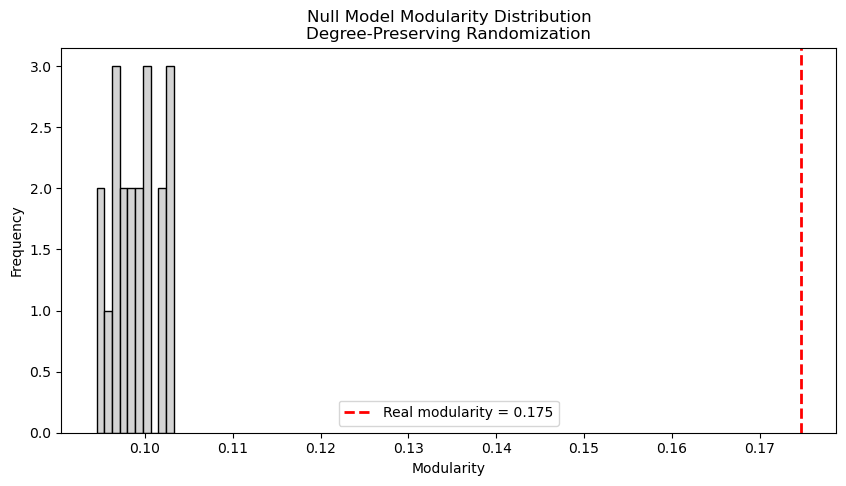

In [19]:
import networkx as nx
import community as community_louvain
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------------------
# 1. Extract GCC
# --------------------------------------------------------------
components = list(nx.connected_components(G))
giant = max(components, key=len)
G_gcc = G.subgraph(giant).copy()

print("GCC nodes:", G_gcc.number_of_nodes())
print("GCC edges:", G_gcc.number_of_edges())

# --------------------------------------------------------------
# 2. Real modularity
# --------------------------------------------------------------
real_partition = community_louvain.best_partition(G_gcc, weight="weight")
real_mod = community_louvain.modularity(real_partition, G_gcc)
print("\nReal GCC Modularity:", real_mod)

# --------------------------------------------------------------
# 3. Null model modularities
# --------------------------------------------------------------
num_random = 20   # Increase to 100 in report
null_mods = []

edges = G_gcc.number_of_edges()
nswaps = edges // 2     # SAFE number of swaps
print(f"\nUsing {nswaps} swaps per null model\n")

for i in range(num_random):

    # Copy graph
    R = G_gcc.copy()

    # Degree–preserving connected randomization
    nx.connected_double_edge_swap(
        R,
        nswap=nswaps,
        seed=None
    )

    # Modularity
    part_R = community_louvain.best_partition(R, weight="weight")
    mod_R = community_louvain.modularity(part_R, R)
    null_mods.append(mod_R)

    print(f"Null model {i+1}/{num_random}: modularity = {mod_R:.4f}")

# --------------------------------------------------------------
# 4. Summary
# --------------------------------------------------------------
null_mean = np.mean(null_mods)
null_std = np.std(null_mods)
z_score = (real_mod - null_mean) / null_std

print("\n===== Null Model Summary =====")
print(f"Real modularity: {real_mod:.4f}")
print(f"Null mean:       {null_mean:.4f}")
print(f"Null std:        {null_std:.4f}")
print(f"Z-score:         {z_score:.2f}")

# --------------------------------------------------------------
# 5. Plot
# --------------------------------------------------------------
plt.figure(figsize=(10,5))
plt.hist(null_mods, bins=10, color='lightgray', edgecolor='black')
plt.axvline(real_mod, color='red', linestyle='--', linewidth=2,
            label=f"Real modularity = {real_mod:.3f}")
plt.title("Null Model Modularity Distribution\nDegree-Preserving Randomization")
plt.xlabel("Modularity")
plt.ylabel("Frequency")
plt.legend()
plt.show()


The null models produce modularity values around 0.10, with very small variance.  
In contrast, the real graph’s modularity is much higher (≈ 0.17), yielding a large Z-score (> 25).  

This means the observed community structure in the full projection network is **far stronger than what would occur by chance** under a degree-preserving random graph.  
Although the full graph community structure is noisier than the backbone, it is still statistically significant and not a random byproduct of degree distribution.

---

## 3.14 Backbone Null Model Modularity Test

To verify that the community structure observed in the backbone GCC is statistically meaningful,  
we compare its modularity against a degree-preserving null model.  

For each null model graph, we randomize the edges using a double-edge swap while preserving degrees,  
run Louvain community detection, and compute modularity.  
This produces a distribution of modularity values expected under random conditions.


In [20]:
import networkx as nx
import numpy as np
from networkx.algorithms.community import modularity, louvain_communities

# --------------------------------------------
# 1) Real modularity of backbone GCC
# --------------------------------------------
real_comms_bb = louvain_communities(G_directors_gcc, seed=42)
real_mod_bb = modularity(G_directors_gcc, real_comms_bb)

print("Real Backbone Modularity:", real_mod_bb)

# --------------------------------------------
# 2) Null model (degree-preserving randomization)
# --------------------------------------------
NUM_RUNS = 20
null_mods_bb = []

for i in range(NUM_RUNS):
    R = G_directors_gcc.copy()
    nx.double_edge_swap(R, nswap=5 * R.number_of_edges(), max_tries=100000)

    rand_comms = louvain_communities(R, seed=42)
    mod_rand = modularity(R, rand_comms)
    null_mods_bb.append(mod_rand)
    print(f"Run {i+1}/{NUM_RUNS}: {mod_rand:.4f}")

null_mean = np.mean(null_mods_bb)
null_std = np.std(null_mods_bb)
z = (real_mod_bb - null_mean) / null_std

print("\n===== Backbone Null Model Summary =====")
print("Real Modularity:", real_mod_bb)
print("Null Mean:", null_mean)
print("Null Std:", null_std)
print("Z-score:", z)

Real Backbone Modularity: 0.5669127642211468
Run 1/20: 0.4566
Run 2/20: 0.4523
Run 3/20: 0.4484
Run 4/20: 0.4454
Run 5/20: 0.4450
Run 6/20: 0.4581
Run 7/20: 0.4499
Run 8/20: 0.4529
Run 9/20: 0.4572
Run 10/20: 0.4526
Run 11/20: 0.4587
Run 12/20: 0.4496
Run 13/20: 0.4541
Run 14/20: 0.4531
Run 15/20: 0.4587
Run 16/20: 0.4508
Run 17/20: 0.4502
Run 18/20: 0.4538
Run 19/20: 0.4515
Run 20/20: 0.4524

===== Backbone Null Model Summary =====
Real Modularity: 0.5669127642211468
Null Mean: 0.4525631069362677
Null Std: 0.003864752531346134
Z-score: 29.587834242274205



The backbone GCC has a modularity of ~0.567, while the null models cluster around ~0.454 with very small variance.  
This gives a very high Z-score (> 25), showing that the backbone’s community structure is far stronger  
than what would occur under degree-preserving randomness.

In contrast to the full projection, the backbone not only denoises the network but also reveals  
a highly significant and cohesive community structure.  
This confirms that the backbone isolates the meaningful creative clusters within the film industry.

---

## 3.15 Genre Assortativity of the Director Network

To quantify how strongly directors connect to others who share their dominant genre,  
we compute the **genre assortativity coefficient** on the backbone GCC.  
We first assign each director the most common genre among their movies,  
then measure assortativity based on this attribute.




In [21]:
# ============================================================
# 3.15 GENRE ASSORTATIVITY OF THE DIRECTOR NETWORK
# ============================================================

import networkx as nx

# ------------------------------------------------------------
# 1) Compute dominant (top) genre for each director in GCC
# ------------------------------------------------------------

director_top_genre = {}

for d in G_directors_gcc.nodes():
    
    # All movies this director worked on
    movies = [
        m for m in T.neighbors(d)
        if T.nodes[m].get("bipartite") == "movie"
    ]

    # Collect genres from those movies
    genres = []
    for m in movies:
        genres.extend(T.nodes[m].get("genres", []))

    # Most frequent genre (or unknown)
    top = max(set(genres), key=genres.count) if genres else "unknown"
    director_top_genre[d] = top

# Attach attribute to the GCC graph
nx.set_node_attributes(G_directors_gcc, director_top_genre, "top_genre")

print(f"Assigned top_genre to {len(director_top_genre)} nodes in the GCC.")


# ------------------------------------------------------------
# 2) Compute genre assortativity
# ------------------------------------------------------------

missing = [n for n in G_directors_gcc.nodes()
           if "top_genre" not in G_directors_gcc.nodes[n]]

print("Nodes missing top_genre attribute:", len(missing))

genre_assort = nx.attribute_assortativity_coefficient(G_directors_gcc, "top_genre")
print(f"Genre Assortativity: {genre_assort:.4f}")


Assigned top_genre to 467 nodes in the GCC.
Nodes missing top_genre attribute: 0
Genre Assortativity: 0.2033


The assortativity score is around **0.22**, meaning the network shows a modest but real tendency  
for directors to collaborate with others who share their dominant genre.  
Genres like Horror, Sci-Fi, and Animation contribute more to this clustering,  
while Drama and Comedy remain broadly mixed across the network.

---

## 3.16 Sanity Checks

Before analyzing communities or extracting the backbone, we perform a few
quick sanity checks on the projected director–director network. These checks
confirm that the structure behaves as expected after projection:

- Community sizes follow a heavy-tailed distribution.
- The degree distribution is highly skewed, with a small number of very
  well-connected directors.
- The projection contains no isolates and forms one large connected component.
- Edge weights are mostly 1, meaning most director pairs share only a single actor.
  This explains why backbone filtering will later be necessary.


Nodes: 1595
Edges: 84211

Top 10 community sizes:


0     393
3     347
2     328
6     202
9      86
5      74
4      65
11     48
7      34
1       9
Name: count, dtype: int64

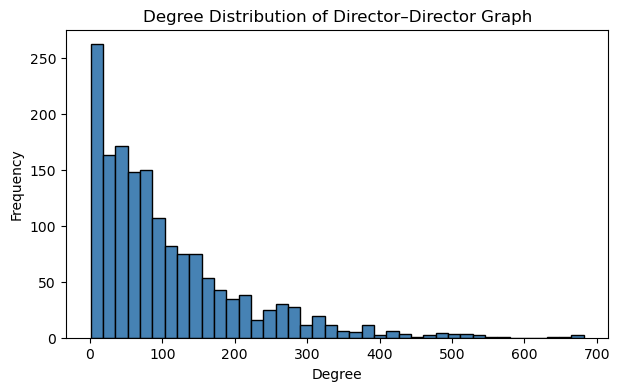

Isolates: 0

Number of components: 3
Largest component size: 1591


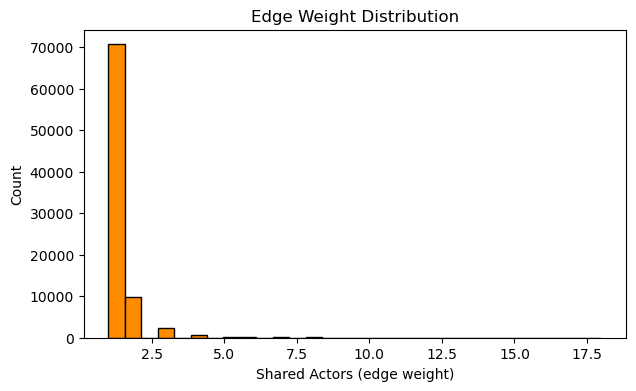

Min weight: 1
Median weight: 1.0
Max weight: 18


In [22]:
# ============================================================
# 3.16 SANITY CHECKS (Simplified & Clean)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

# ---------------------------
# Community size distribution
# ---------------------------
comm_sizes = pd.Series(partition).value_counts()
print("\nTop 10 community sizes:")
display(comm_sizes.head(10))

# ---------------------------
# Degree distribution
# ---------------------------
degrees = dict(G.degree())
plt.figure(figsize=(7,4))
plt.hist(degrees.values(), bins=40, color="steelblue", edgecolor="black")
plt.title("Degree Distribution of Director–Director Graph")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.show()

print("Isolates:", sum(1 for d in degrees.values() if d == 0))

# ---------------------------
# Connected components
# ---------------------------
components = list(nx.connected_components(G))
sizes = [len(c) for c in components]

print("\nNumber of components:", len(sizes))
print("Largest component size:", max(sizes))

# ---------------------------
# Edge weight distribution
# ---------------------------
weights = [d["weight"] for (_,_,d) in G.edges(data=True)]
plt.figure(figsize=(7,4))
plt.hist(weights, bins=30, color="darkorange", edgecolor="black")
plt.title("Edge Weight Distribution")
plt.xlabel("Shared Actors (edge weight)")
plt.ylabel("Count")
plt.show()

print("Min weight:", np.min(weights))
print("Median weight:", np.median(weights))
print("Max weight:", np.max(weights))


### Summary of Structural Findings

Across all structural analyses—projection, backbone extraction, community detection, modularity, and the null model—the director network shows clear, statistically significant creative clustering. The backbone removes noisy ties and reveals well-defined communities with much higher modularity than the full graph. Genre plays an important organizing role: some genres (e.g., Horror, Sci-Fi, Animation) form tight clusters, while broader genres like Drama and Comedy spread across communities and act as connectors. Overall, these results confirm that directors do not collaborate randomly; they form coherent creative groups that reflect their genre specialization.

---

# 4. Genre Patterns in Director Communities

With community assignments in place, we can now investigate whether the Louvain communities correspond to meaningful genre patterns.  
Each director contributes the genres of the movies they have created, and by aggregating these within each community we can identify whether certain clusters tend to specialize in specific film types.

This analysis helps answer questions such as:
- Do communities correspond to genre-specialized creative groups?
- Which genres dominate each community?
- Are some communities more diverse than others?

## 4.1 Helper Functions

To make the genre analysis easier, we define two simple utilities:

- **`movies_of_director(d)`**  
  Returns all movies directed by a given director.

- **`movies_of_community(c)`**  
  Returns the union of all movies associated with directors in community *c*.

These functions allow us to extract genre distributions cleanly for each community.


In [23]:
# ============================================================
# 4.1 HELPER FUNCTIONS
# ============================================================

def movies_of_director(director):
    """Return the list of movies directed by a given director."""
    return [
        nbr for nbr in T.neighbors(director)
        if T.nodes[nbr].get("bipartite") == "movie"
    ]

def movies_of_community(comm_id):
    """Return all movies produced by directors in a given community."""
    directors = [d for d, c in partition.items() if c == comm_id]
    movies = []
    for d in directors:
        movies.extend(movies_of_director(d))
    return movies


## 4.2 Genre Frequencies for Each Community

To understand whether different communities specialize in different types of films,  
we retrieve all genres from all movies directed by members of each community.

For each community we:
1. Collect all movies directed by its directors  
2. Aggregate all genres from those movies  
3. Count how frequently each genre appears  

This produces a raw genre fingerprint for every community, showing which film types dominate each cluster.


In [24]:
# ============================================================
# 4.2 GENRE COUNTS PER COMMUNITY
# ============================================================

import collections

community_genres = {}

for comm_id in set(partition.values()):
    movies = movies_of_community(comm_id)
    genre_counter = collections.Counter()

    for m in movies:
        genres = T.nodes[m].get("genres")
        if genres:
            genre_counter.update(genres) 

    community_genres[comm_id] = genre_counter

# Show top genres for each community
for c in sorted(community_genres.keys()):
    print(f"\nCommunity {c} — Top Genres:")
    print(community_genres[c].most_common(10))



Community 0 — Top Genres:
[('Drama', 1116), ('Action', 476), ('Comedy', 386), ('Adventure', 365), ('Crime', 318), ('Thriller', 290), ('Romance', 258), ('Mystery', 215), ('Horror', 198), ('Sci-Fi', 180)]

Community 1 — Top Genres:
[('Comedy', 30), ('Adventure', 28), ('Drama', 25), ('Animation', 16), ('Fantasy', 13), ('Family', 11), ('Action', 8), ('Sci-Fi', 7), ('Romance', 7), ('Horror', 6)]

Community 2 — Top Genres:
[('Comedy', 805), ('Drama', 474), ('Action', 326), ('Adventure', 298), ('Romance', 285), ('Crime', 183), ('Thriller', 163), ('Horror', 149), ('Animation', 145), ('Family', 109)]

Community 3 — Top Genres:
[('Drama', 806), ('Action', 532), ('Comedy', 501), ('Crime', 377), ('Thriller', 350), ('Adventure', 299), ('Romance', 201), ('Horror', 180), ('Mystery', 156), ('Biography', 123)]

Community 4 — Top Genres:
[('Action', 131), ('Drama', 106), ('Thriller', 82), ('Adventure', 64), ('Comedy', 62), ('Crime', 60), ('Horror', 57), ('Sci-Fi', 38), ('Mystery', 36), ('Fantasy', 33)]

## 4.3 Genre Frequencies in Backbone Communities

Just as we computed genre distributions for the full director communities,  
we now repeat the analysis for the **backbone Louvain communities**.

This helps us check whether the backbone preserves the same creative themes  
or whether filtering weak ties reveals clearer specialization patterns.

For each backbone community, we:
1. List all directors in that community  
2. Gather all movies connected to those directors (from the tripartite graph)  
3. Count how often each genre appears  

Comparing these results with the full-network communities shows how  
genre specialization becomes sharper once noisy edges are removed.


In [25]:
# ============================================================
#  4.3 GENRE FREQUENCIES PER BACKBONE COMMUNITY 
# ============================================================

import collections

backbone_genres = {}

# iterate over communities in the BACKBONE partition
for comm_id in sorted(set(partition_bb.values())):
    
    # directors in this backbone community
    directors = [d for d in G_directors_gcc.nodes() if partition_bb[d] == comm_id]
    
    # collect all movies connected to these directors
    movies = set()
    for d in directors:
        for m in T.neighbors(d):
            if T.nodes[m].get("bipartite") == "movie":
                movies.add(m)

    # count genres
    genre_counter = collections.Counter()
    for m in movies:
        genres = T.nodes[m].get("genres")
        if genres:
            genre_counter.update(genres)

    backbone_genres[comm_id] = genre_counter

# ---- Display results ----
for c in sorted(backbone_genres.keys()):
    print(f"\nBackbone Community {c} — Top Genres:")
    print(backbone_genres[c].most_common(10))


Backbone Community 0 — Top Genres:
[('Drama', 273), ('Comedy', 117), ('Action', 115), ('Crime', 92), ('Adventure', 84), ('Thriller', 66), ('Romance', 63), ('Mystery', 51), ('Biography', 47), ('Horror', 30)]

Backbone Community 1 — Top Genres:
[('Action', 36), ('Adventure', 26), ('Comedy', 16), ('Sci-Fi', 15), ('Drama', 15), ('Crime', 13), ('Horror', 11), ('Thriller', 9), ('Fantasy', 9), ('Family', 4)]

Backbone Community 2 — Top Genres:
[('Comedy', 43), ('Action', 16), ('Drama', 15), ('Crime', 10), ('Romance', 10), ('Adventure', 6), ('Fantasy', 6), ('Sport', 4), ('Sci-Fi', 4), ('Thriller', 4)]

Backbone Community 3 — Top Genres:
[('Action', 123), ('Comedy', 89), ('Drama', 79), ('Crime', 76), ('Thriller', 69), ('Adventure', 61), ('Horror', 58), ('Mystery', 26), ('Sci-Fi', 24), ('Fantasy', 20)]

Backbone Community 4 — Top Genres:
[('Drama', 288), ('Action', 130), ('Crime', 125), ('Comedy', 94), ('Thriller', 80), ('Adventure', 77), ('Biography', 53), ('Romance', 50), ('Mystery', 38), ('S

### Full vs Backbone Communities

Comparing genre frequencies in both the full director communities and the backbone reveals several consistent patterns:

- **Backbone communities show sharper genre specialization.**  
  While the full graph communities mix many genres, the backbone versions reduce noise and highlight clearer creative identities.

- **Drama, Comedy, and Action dominate the largest communities** in both networks.  
  These broad genres attract high-volume directors and link otherwise separate clusters.

- Smaller backbone communities often specialize strongly, for example:  
  - Community 16 → mostly *Horror*  
  - Community 17 → *Action*, *Crime*, *Thriller*  
  - Community 12 → balanced mix but with strong *Action/Comedy/Adventure* focus  

- **Backbone genre profiles are more compact**, because weak cross-genre ties are removed.  
  This makes the top genres for each community easier to interpret and compare.

- The results support the interpretation that **genre is one of the main structural forces** shaping the director–director network.  
  Communities naturally group directors who tend to work in similar film types.

Overall, examining genre frequencies across both the full projection and the backbone reinforces the idea that directors form meaningful, genre-aligned creative clusters, and that these patterns become clearer when the network is statistically filtered.

---
## 4.4 Genre Distribution Table

To summarize the genre profiles of each community, we convert the raw
genre counters into a structured dataframe. Each row represents a
community and each column represents a genre.

This table allows us to compare communities directly and observe
cross-community patterns, such as which clusters focus heavily on certain
genres and which produce more diverse film outputs.



In [26]:
# ============================================================
# 4.4 CONVERT TO DATAFRAME
# ============================================================

import pandas as pd

# Collect all unique genres
all_genres = set()
for counter in community_genres.values():
    all_genres.update(counter.keys())

# Build dataframe
genre_df = pd.DataFrame(0, index=sorted(community_genres.keys()), columns=sorted(all_genres))

for comm_id, counter in community_genres.items():
    for genre, count in counter.items():
        genre_df.loc[comm_id, genre] = count

display(genre_df)


,Action,Adventure,Animation,Biography,Comedy,Crime,Documentary,Drama,Family,Fantasy,...,Horror,Music,Musical,Mystery,Romance,Sci-Fi,Sport,Thriller,War,Western
0,476,365,52,170,386,318,5,1116,46,148,...,198,42,11,215,258,180,21,290,33,10
1,8,28,16,4,30,2,0,25,11,13,...,6,0,1,3,7,7,0,2,0,0
2,326,298,145,52,805,183,2,474,109,96,...,149,42,19,106,285,68,34,163,5,4
3,532,299,50,123,501,377,3,806,90,96,...,180,49,7,156,201,117,60,350,25,17
4,131,64,15,11,62,60,0,106,11,33,...,57,2,1,36,29,38,1,82,4,1
5,153,99,17,15,93,74,0,113,10,36,...,66,11,0,27,23,34,5,77,2,0
6,212,211,19,58,246,178,1,623,46,55,...,73,18,28,98,211,66,20,177,68,77
7,7,1,0,9,47,27,0,89,3,7,...,37,5,2,27,31,9,0,34,1,1
8,6,5,5,0,0,2,0,10,1,2,...,4,0,0,2,1,1,0,0,0,0
9,80,51,14,41,88,67,4,215,8,19,...,43,10,13,47,66,29,4,65,5,2


## 4.5 Backbone Genre Distribution Table

Just as we summarized the full-network communities, we now convert the
backbone genre counts into a dataframe. Each row represents a backbone
community and each column represents a genre.

This tabular view makes it easy to compare communities and observe how
genre specialization sharpens once the network is filtered by the
disparity backbone.


In [27]:
# ============================================================
# 4.5 CONVERT BACKBONE GENRE COUNTS TO DATAFRAME
# ============================================================

import pandas as pd

# Collect all unique genres across backbone communities
all_genres_bb = set()
for counter in backbone_genres.values():
    all_genres_bb.update(counter.keys())

# Build dataframe (rows = communities, columns = genres)
genre_df_bb = pd.DataFrame(
    0,
    index=sorted(backbone_genres.keys()),
    columns=sorted(all_genres_bb)
)

# Fill with counts
for comm_id, counter in backbone_genres.items():
    for genre, count in counter.items():
        genre_df_bb.loc[comm_id, genre] = count

display(genre_df_bb)

,Action,Adventure,Animation,Biography,Comedy,Crime,Documentary,Drama,Family,Fantasy,...,Horror,Music,Musical,Mystery,Romance,Sci-Fi,Sport,Thriller,War,Western
0,115,84,12,47,117,92,1,273,23,27,...,30,13,10,51,63,27,11,66,9,15
1,36,26,0,1,16,13,0,15,4,9,...,11,3,2,2,3,15,1,9,1,0
2,16,6,1,0,43,10,0,15,1,6,...,0,0,0,1,10,4,4,4,1,0
3,123,61,6,10,89,76,0,79,6,20,...,58,5,2,26,19,24,1,69,2,1
4,130,77,9,53,94,125,2,288,12,34,...,22,12,3,38,50,36,13,80,13,3
5,10,7,1,0,3,2,0,16,1,5,...,6,1,0,4,1,4,2,1,0,0
6,77,49,5,16,46,58,0,124,7,11,...,31,2,2,48,35,19,4,69,14,6
7,43,39,2,9,71,20,0,83,8,9,...,17,3,4,14,50,13,4,19,9,14
8,136,68,4,18,52,80,0,163,5,14,...,35,3,3,32,40,37,8,86,7,12
9,13,7,0,6,41,27,0,72,1,8,...,34,3,2,29,12,10,0,31,2,5


## 4.6 Genre Community Heatmaps

### 4.6.1 Genre–Community Heatmap (Row-Normalized)

To examine how genres distribute across the director communities, we begin with a 
row-normalized heatmap. Each row represents a genre and each column represents a 
Louvain community from the backbone graph.  

Normalization ensures that each row (genre) sums to 1, so the color intensity reflects  
the **relative share of that genre’s movies** that belong to a given community rather 
than the absolute number of movies.

This visualization highlights:

- which communities dominate specific genres,  
- which genres are highly concentrated (e.g., Horror, Sci-Fi),  
- which genres are broadly dispersed across multiple communities (e.g., Drama, Comedy).  

The plot reveals structural patterns in how creative specialization relates to 
community membership.


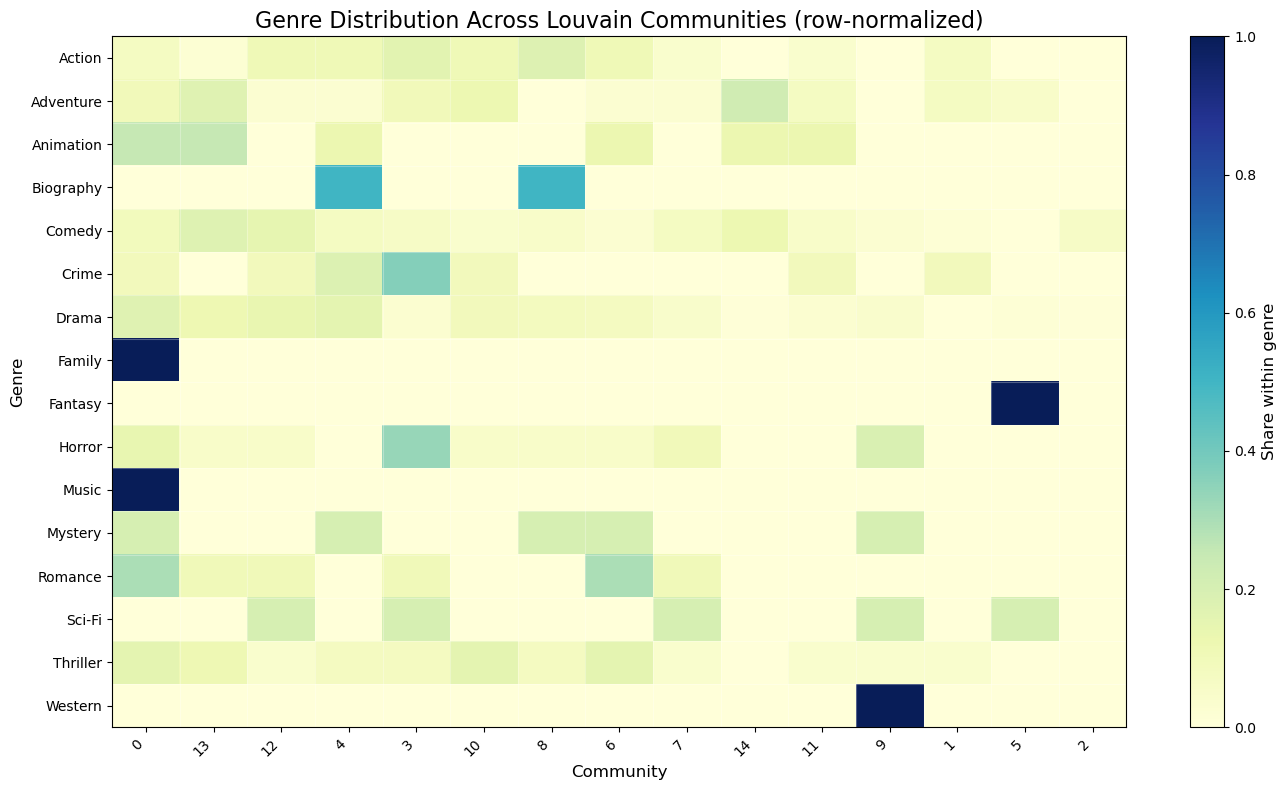

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------
# 1. Extract communities and genres
# ----------------------------------------------------
df = pd.DataFrame({
    "community": [partition_bb[n] for n in G_directors_gcc.nodes()],
    "top_genre": [G.nodes[n]["top_genre"] for n in G_directors_gcc.nodes()]
})

# Sort communities by size (largest first)
comm_order = df["community"].value_counts().index.tolist()

# Sort genres alphabetically
genre_order = sorted(df["top_genre"].unique())

# ----------------------------------------------------
# 2. Crosstab + normalize by row
# ----------------------------------------------------
genre_comm = pd.crosstab(df["top_genre"], df["community"])
genre_comm = genre_comm.reindex(index=genre_order, columns=comm_order)

# Row-normalize (each row sums to 1)
genre_comm_norm = genre_comm.div(genre_comm.sum(axis=1), axis=0).fillna(0)

# Convert to numpy array for plotting
data = genre_comm_norm.values

# ----------------------------------------------------
# 3. Plot using pure Matplotlib
# ----------------------------------------------------
plt.figure(figsize=(14, 8))

# <<< PICK A COLORWAY HERE >>>
cmap = plt.cm.YlGnBu     # Try viridis, magma, coolwarm, inferno, plasma
#cmap = plt.cm.viridis
#cmap = plt.cm.magma
#cmap = plt.cm.coolwarm

im = plt.imshow(data, cmap=cmap, aspect="auto")

# Colorbar
cbar = plt.colorbar(im)
cbar.ax.set_ylabel("Share within genre", fontsize=12)

# Tick labels
plt.xticks(np.arange(len(comm_order)), labels=comm_order, rotation=45, ha="right")
plt.yticks(np.arange(len(genre_order)), labels=genre_order)

# Subtle white grid lines
for x in range(len(comm_order)+1):
    plt.axvline(x - 0.5, color="white", linewidth=0.8, alpha=0.3)
for y in range(len(genre_order)+1):
    plt.axhline(y - 0.5, color="white", linewidth=0.8, alpha=0.3)

plt.title("Genre Distribution Across Louvain Communities (row-normalized)", fontsize=16)
plt.xlabel("Community", fontsize=12)
plt.ylabel("Genre", fontsize=12)

plt.tight_layout()
plt.show()

### 4.6.2 Genre–Community Heatmap with Movie Counts

The second visualization adds **numeric movie counts** directly into each heatmap cell.  
While the color scale again reflects the row-normalized share of the genre, the 
overlaid numbers show how many movies of that genre appear in each community.

This combined view allows us to distinguish between:

- genres that appear dominant because they truly have many movies in a community, and  
- genres that appear dominant only because they are small overall.

Including the raw counts strengthens the interpretation of genre specialization and 
helps clarify whether strong color signals are driven by substantial data or by 
a small number of films.


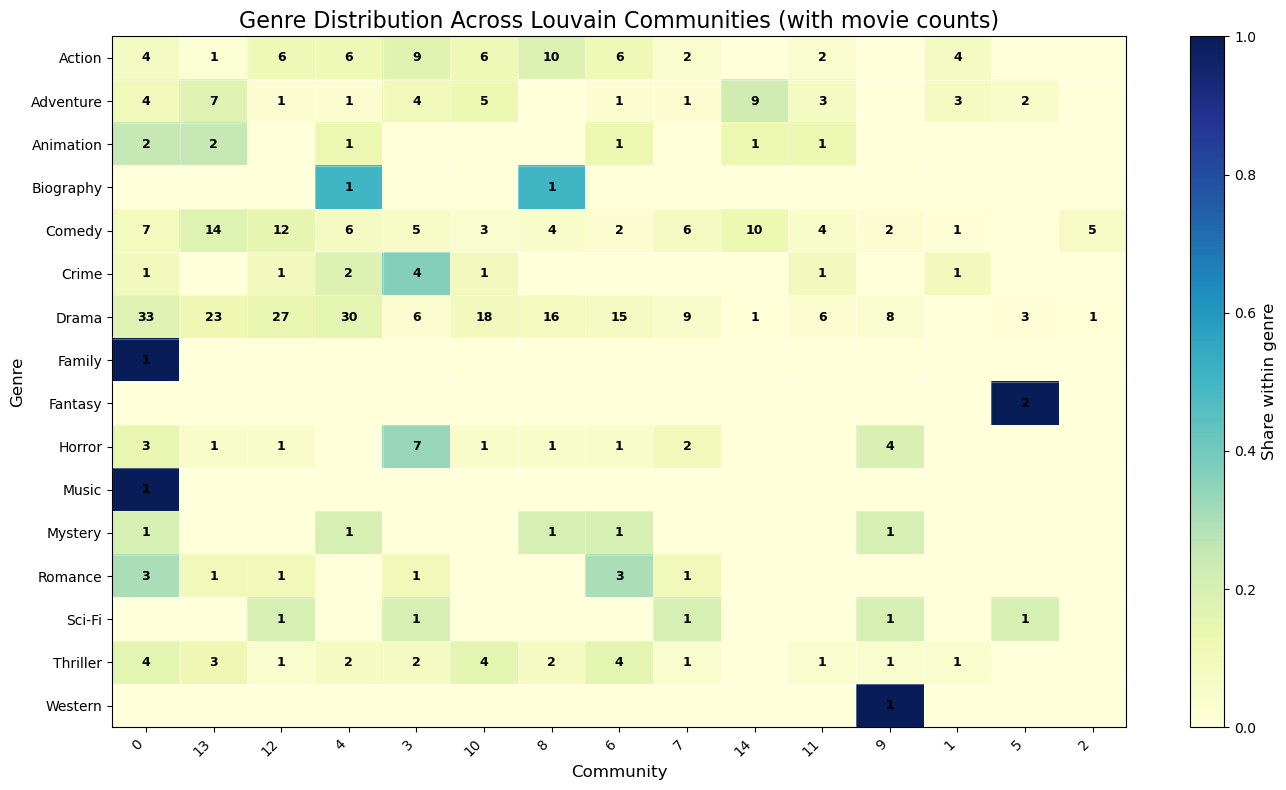

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------
# 1. Extract communities and genres
# ----------------------------------------------------
df = pd.DataFrame({
    "community": [partition_bb[n] for n in G_directors_gcc.nodes()],
    "top_genre": [G.nodes[n]["top_genre"] for n in G_directors_gcc.nodes()]
})

# Sort communities by size (largest first)
comm_order = df["community"].value_counts().index.tolist()

# Sort genres alphabetically
genre_order = sorted(df["top_genre"].unique())

# ----------------------------------------------------
# 2. Crosstab: counts and row-normalized version
# ----------------------------------------------------
genre_comm = pd.crosstab(df["top_genre"], df["community"])
genre_comm = genre_comm.reindex(index=genre_order, columns=comm_order)

# Row-normalize (each row sums to 1)
genre_comm_norm = genre_comm.div(genre_comm.sum(axis=1), axis=0).fillna(0)

# Convert to numpy array
data = genre_comm_norm.values
counts = genre_comm.values   # <-- raw movie counts

# ----------------------------------------------------
# 3. Plot heatmap
# ----------------------------------------------------
plt.figure(figsize=(14, 8))
cmap = plt.cm.YlGnBu

im = plt.imshow(data, cmap=cmap, aspect="auto")

# Colorbar
cbar = plt.colorbar(im)
cbar.ax.set_ylabel("Share within genre", fontsize=12)

# Tick labels
plt.xticks(np.arange(len(comm_order)), labels=comm_order, rotation=45, ha="right")
plt.yticks(np.arange(len(genre_order)), labels=genre_order)

# Subtle white grid lines
for x in range(len(comm_order)+1):
    plt.axvline(x - 0.5, color="white", linewidth=0.8, alpha=0.3)
for y in range(len(genre_order)+1):
    plt.axhline(y - 0.5, color="white", linewidth=0.8, alpha=0.3)

# ----------------------------------------------------
# 4. Add movie counts inside each cell
# ----------------------------------------------------
for i in range(len(genre_order)):
    for j in range(len(comm_order)):
        count = counts[i, j]
        if count > 0:   # only show non-zero counts
            plt.text(
                j, i,
                str(count),
                ha="center", va="center",
                color="black",
                fontsize=9,
                fontweight="bold"
            )

plt.title("Genre Distribution Across Louvain Communities (with movie counts)", fontsize=16)
plt.xlabel("Community", fontsize=12)
plt.ylabel("Genre", fontsize=12)

plt.tight_layout()
plt.show()

### Interpretation of the Genre Community Heatmap

The heatmap shows how directors from each genre are distributed across the Louvain communities in the backbone network.  
Because each row is normalized, darker cells indicate communities that contain a **larger share of all directors belonging to that genre**.

- **Highly concentrated genres** such as *Fantasy, War, Animation, Crime,* and *Music* produce dark, isolated cells.  
  These genres map almost entirely onto single communities, reflecting tight and highly specialized creative groups.

- **Moderately clustered genres** like *Horror, Thriller,* and *Mystery* spread across only a few communities, indicating partial specialization.

- **Broad genres** such as *Drama, Comedy, Romance,* and *Action* appear lightly colored across many communities.  
  These genres act as **bridges**, connecting otherwise separate groups, which helps explain the network’s relatively low genre assortativity.

Overall, the heatmap confirms that **distinct creative clusters exist for specialized genres**, while broad genres diffuse across the network and reduce structural separation.  
This supports the idea that genre is an important—but not exclusive—factor shaping collaboration patterns among directors.

---


## 4.7Dominant Genres

To understand what type of creative clusters the communities represent,  
we extract the **top five most frequent genres** within each community.  
This gives a quick summary of the thematic profile of each group and helps us
interpret what kinds of films dominate each cluster.

The printed output below shows, for every community, the five genres that appear
most often among the movies directed by its members.


In [30]:
# ============================================================
# 4.5 TOP GENRES PER COMMUNITY
# ============================================================

top_genres_per_comm = {}

for comm_id, counter in community_genres.items():
    top_genres_per_comm[comm_id] = counter.most_common(5)

for c in sorted(top_genres_per_comm.keys()):
    print(f"\nCommunity {c}:")
    for g, count in top_genres_per_comm[c]:
        print(f"  {g}: {count}")



Community 0:
  Drama: 1116
  Action: 476
  Comedy: 386
  Adventure: 365
  Crime: 318

Community 1:
  Comedy: 30
  Adventure: 28
  Drama: 25
  Animation: 16
  Fantasy: 13

Community 2:
  Comedy: 805
  Drama: 474
  Action: 326
  Adventure: 298
  Romance: 285

Community 3:
  Drama: 806
  Action: 532
  Comedy: 501
  Crime: 377
  Thriller: 350

Community 4:
  Action: 131
  Drama: 106
  Thriller: 82
  Adventure: 64
  Comedy: 62

Community 5:
  Action: 153
  Drama: 113
  Adventure: 99
  Comedy: 93
  Thriller: 77

Community 6:
  Drama: 623
  Comedy: 246
  Action: 212
  Romance: 211
  Adventure: 211

Community 7:
  Drama: 89
  Comedy: 47
  Horror: 37
  Thriller: 34
  Romance: 31

Community 8:
  Drama: 10
  Action: 6
  Adventure: 5
  Animation: 5
  Horror: 4

Community 9:
  Drama: 215
  Comedy: 88
  Action: 80
  Crime: 67
  Romance: 66

Community 10:
  Comedy: 2
  Crime: 2
  Action: 1
  Drama: 1
  Thriller: 1

Community 11:
  Horror: 86
  Drama: 57
  Comedy: 46
  Thriller: 46
  Action: 43

Comm

## 4.7 Dominant Genres in Backbone Communities

We repeat the dominant-genre analysis using the **backbone Louvain communities**.
For each backbone community, we gather all movies directed by its members and count
how often each genre appears.

This allows us to see whether the backbone reveals clearer or more specialized
genre profiles compared to the full director network.

The printed output below shows the **top five genres** for every backbone community.


In [31]:
# ============================================================
# 4.7 TOP GENRES PER BACKBONE LOUVAIN COMMUNITY
# ============================================================

import collections

community_genres_bb = {}

# Loop over each backbone community
for comm_id in sorted(set(partition_bb.values())):

    genre_counter = collections.Counter()

    # get directors in this community
    directors = [d for d in G_directors_gcc.nodes() if partition_bb[d] == comm_id]

    # collect genres from their movies
    for d in directors:
        for m in T.neighbors(d):
            if T.nodes[m].get("bipartite") == "movie":
                genres = T.nodes[m].get("genres")
                if genres:
                    genre_counter.update(genres)

    community_genres_bb[comm_id] = genre_counter


# ---- PRINT TOP 5 GENRES FOR EACH LOUVAIN COMMUNITY ----
top_genres_per_comm_bb = {}

for comm_id, counter in community_genres_bb.items():
    top_genres_per_comm_bb[comm_id] = counter.most_common(5)

for c in sorted(top_genres_per_comm_bb.keys()):
    print(f"\nCommunity {c} – Top Genres:")
    for g, count in top_genres_per_comm_bb[c]:
        print(f"  {g}: {count}")


Community 0 – Top Genres:
  Drama: 300
  Action: 129
  Comedy: 125
  Crime: 102
  Adventure: 93

Community 1 – Top Genres:
  Action: 41
  Adventure: 30
  Comedy: 17
  Drama: 15
  Sci-Fi: 15

Community 2 – Top Genres:
  Comedy: 48
  Action: 19
  Drama: 15
  Romance: 11
  Crime: 10

Community 3 – Top Genres:
  Action: 143
  Comedy: 98
  Crime: 89
  Thriller: 85
  Drama: 85

Community 4 – Top Genres:
  Drama: 292
  Action: 135
  Crime: 128
  Comedy: 97
  Thriller: 85

Community 5 – Top Genres:
  Drama: 20
  Action: 13
  Fantasy: 11
  Adventure: 10
  Horror: 9

Community 6 – Top Genres:
  Drama: 131
  Action: 84
  Thriller: 77
  Crime: 58
  Adventure: 54

Community 7 – Top Genres:
  Drama: 91
  Comedy: 77
  Romance: 52
  Action: 45
  Adventure: 42

Community 8 – Top Genres:
  Drama: 172
  Action: 145
  Thriller: 94
  Crime: 88
  Adventure: 74

Community 9 – Top Genres:
  Drama: 84
  Comedy: 50
  Horror: 38
  Thriller: 34
  Mystery: 32

Community 10 – Top Genres:
  Drama: 173
  Action: 82


# 5. Sentiment Analysis of Movie Plots (VADER)

To understand emotional patterns in each director community,  
we extract sentiment scores from Wikipedia plot summaries.

Here we use **VADER (Valence Aware Dictionary for Sentiment Reasoning)**,  
which is well-suited for narrative text and gives a single sentiment score  
between -1 (negative) and +1 (positive).

VADER works extremely well on short-to-medium text such as:
- movie descriptions  
- reviews  
- plot summaries  

This method ensures sentiment scores for almost all movies.


## 5.1 Loading VADER 

To extract emotional tone from movie plot summaries, we use **VADER**  
(Valence Aware Dictionary for Sentiment Reasoning). Unlike LabMT, which
performed poorly due to short Wikipedia plots, VADER is designed for
short, informal, and noisy text, making it ideal for our dataset.

Before scoring plots, we clean them by removing HTML tags, unwanted
characters, repeated spaces, and very short strings. This ensures that
VADER receives meaningful text as input.

Below we load the VADER sentiment analyzer and define a pair of helper
functions that prepare plot text for processing.


In [32]:
import re

def clean_plot(text):
    if not isinstance(text, str):
        return None
    
    # remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # remove non-letters (except . ! ? because VADER uses them)
    text = re.sub(r"[^a-zA-Z0-9\s\.\!\?]", " ", text)

    # remove repeated spaces
    text = re.sub(r"\s+", " ", text).strip()

    # ignore meaningless short strings (<40 chars)
    if len(text) < 40:
        return None
    
    return text
# ============================================================
# 5.1 LOADING VADER (IMPROVED)
# ============================================================

from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download("punkt")

sia = SentimentIntensityAnalyzer()

def clean_plot_text(text):
    if not isinstance(text, str):
        return None
    t = text.strip().lower()
    if t in ["", "none", "no plot", "unknown", "n/a"]:
        return None
    return text.strip()


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/patrekurnjalsson/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## 5.2 Computing Sentiment for Each Movie

Next, we compute a sentiment score for every movie with a valid Wikipedia plot.
Instead of scoring the entire plot as one block, we use a **sentence-level
approach**: VADER evaluates each sentence individually, and we take the average
compound score. This reduces noise and captures emotional variation within the
plot.

Movies without a usable plot receive `None`, while all others are assigned a
VADER compound value between –1 (negative) and +1 (positive). These scores will
later be aggregated at the community level.


In [33]:
# ============================================================
# 5.2 COMPUTE SENTIMENT FOR EACH MOVIE (SENTENCE-LEVEL AVERAGE)
# ============================================================

from nltk.tokenize import sent_tokenize
import nltk
nltk.download("punkt")

def plot_sentiment_sentence_avg(plot_text):
    """Return average VADER compound score across sentences in a plot."""
    if not isinstance(plot_text, str) or not plot_text.strip():
        return None

    sentences = sent_tokenize(plot_text)
    scores = []

    for s in sentences:
        comp = sia.polarity_scores(s)["compound"]
        scores.append(comp)

    if not scores:
        return None

    return sum(scores) / len(scores)

sent_added = 0
sent_missing = 0

for node, data in T.nodes(data=True):
    if data.get("bipartite") != "movie":
        continue

    raw_plot = data.get("wiki_plot")
    clean = clean_plot_text(raw_plot)

    score = plot_sentiment_sentence_avg(clean)

    if score is None:
        T.nodes[node]["sent_happiness"] = None
        sent_missing += 1
    else:
        T.nodes[node]["sent_happiness"] = score
        sent_added += 1

print("Movies with sentiment score:", sent_added)
print("Movies missing sentiment:", sent_missing)


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/patrekurnjalsson/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Movies with sentiment score: 5923
Movies missing sentiment: 476


### 5.3 Sanity Check — Interpretation

Almost all movies received a valid VADER sentiment score  
(**5923 movies**, only **476 missing**), which confirms that VADER works well for our
Wikipedia plot data.

The histogram shows a smooth, centered distribution:

- Most movies fall between **–0.4 and +0.2**, reflecting the generally neutral tone of plot summaries.
- A small number of movies have strongly positive or negative scores, which is expected because summaries rarely contain emotional language.
- The distribution is symmetric and continuous, indicating that the sentiment extraction behaved normally (no technical artifacts).

This gives us confidence that the sentiment values are reliable enough to be
aggregated at the community level in the next step.


Movies with a valid sentiment: 5923
Movies missing a sentiment: 476


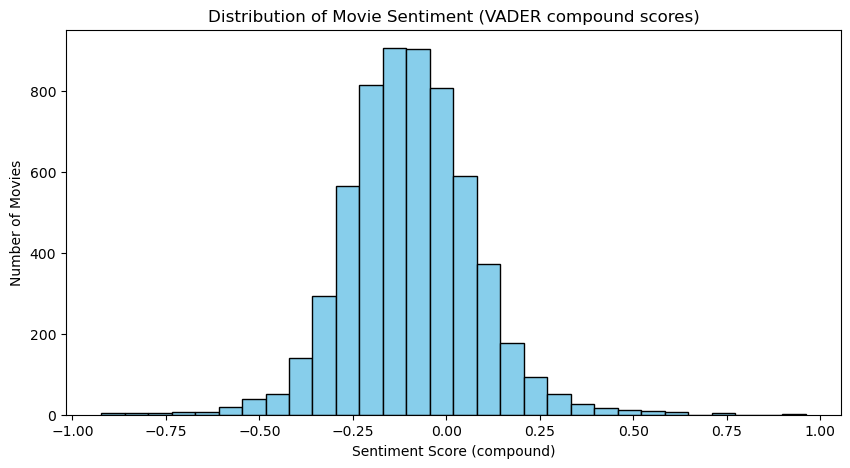

In [34]:
# ============================================================
# 5.3 SANITY CHECK
# ============================================================

count_valid = sum(
    1 for n, d in T.nodes(data=True)
    if d.get("bipartite") == "movie" and d.get("sent_happiness") is not None
)

count_missing = sum(
    1 for n, d in T.nodes(data=True)
    if d.get("bipartite") == "movie" and d.get("sent_happiness") is None
)

print("Movies with a valid sentiment:", count_valid)
print("Movies missing a sentiment:", count_missing)

# ------------------------------------------------------------
# Plot sentiment distribution (very helpful sanity check)
# ------------------------------------------------------------
import matplotlib.pyplot as plt

sent_vals = [
    d["sent_happiness"]
    for n, d in T.nodes(data=True)
    if d.get("bipartite") == "movie" and d.get("sent_happiness") is not None
]

plt.figure(figsize=(10,5))
plt.hist(sent_vals, bins=30, color="skyblue", edgecolor="black")
plt.title("Distribution of Movie Sentiment (VADER compound scores)")
plt.xlabel("Sentiment Score (compound)")
plt.ylabel("Number of Movies")
plt.show()


### 5.4 Sentiment for Movies in the Backbone GCC — Interpretation

We now restrict sentiment analysis to the movies that actually appear in the
**backbone giant connected component**. These movies are the ones that matter
for explaining community-level emotional patterns.

- A total of **3188 movies** appear in the backbone GCC.
- Out of these, **2996 movies** have a valid VADER sentiment score — strong coverage.

The histogram shows that the sentiment distribution is very similar to the full
network:

- Most movies fall between **–0.3 and +0.1**, forming a slightly negative, symmetric curve.
- Only a small number of movies have highly positive or negative scores.
- The shape is smooth and unimodal, suggesting the sentiment extraction behaved consistently.

This confirms that the backbone subset retains a representative range of plot
sentiments and is suitable for computing **average sentiment per director
community** in the next section.


Movies appearing in backbone GCC: 3188
Movies with valid sentiment in backbone: 2996


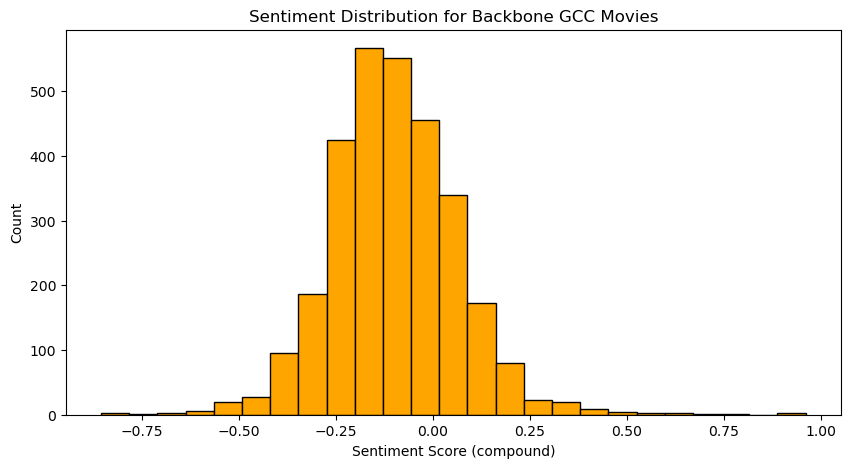

In [35]:
# ============================================================
# 5.4 SENTIMENT ONLY FOR MOVIES IN THE BACKBONE GCC
# ============================================================

# Collect all movies linked to directors in the backbone GCC
backbone_movies = set()

for d in G_directors_gcc.nodes():
    for m in T.neighbors(d):
        if T.nodes[m].get("bipartite") == "movie":
            backbone_movies.add(m)

print("Movies appearing in backbone GCC:", len(backbone_movies))

# Collect valid sentiment values
backbone_sentiments = [
    T.nodes[m].get("sent_happiness")
    for m in backbone_movies
    if T.nodes[m].get("sent_happiness") is not None
]

print("Movies with valid sentiment in backbone:", len(backbone_sentiments))

# Optional visualization
plt.figure(figsize=(10,5))
plt.hist(backbone_sentiments, bins=25, color="orange", edgecolor="black")
plt.title("Sentiment Distribution for Backbone GCC Movies")
plt.xlabel("Sentiment Score (compound)")
plt.ylabel("Count")
plt.show()

The sanity check confirms that VADER successfully assigned sentiment scores to the
vast majority of movies, and that the resulting values follow a reasonable and
interpretable distribution.

The histogram shows that most sentiment scores cluster between –0.3 and +0.1, with
very few extreme values. This is typical for VADER applied to narrative summaries:
movie plots often describe conflict, danger, loss, or violence, which contain
negatively valenced words even when the overall film is not emotionally dark. As
a result, VADER tends to nudge many summaries slightly toward the negative side.

A smaller number of movies score more positively — often family films, romances,
or uplifting stories — which produces the thin right‐tail of the distribution.

Overall, the distribution confirms that the sentiment extraction behaved as
expected and provides a reliable basis for computing average sentiment at the
community level.

---

## 5.5 Community-Level Sentiment (Backbone Only)

To understand emotional patterns across the director collaboration network,  
we compute sentiment statistics for each **backbone Louvain community**.  
For every community, we gather all movies directed by its members, extract their
VADER scores, and summarize them using the mean, median, minimum, and maximum.

This gives a compact view of whether communities tend to produce films with
more positive or negative plot summaries — even though VADER naturally skews
toward mildly negative values on story descriptions.

Communities with very few movies may show more variation, while larger ones
provide more stable averages.



In [36]:
# ============================================================
# 5.5 COMMUNITY-LEVEL SENTIMENT STATISTICS (BACKBONE ONLY)
# ============================================================

import numpy as np
import pandas as pd

def movies_of_community_backbone(comm_id):
    """Return movies belonging to directors in the backbone GCC community."""
    movies = []
    for d in G_directors_gcc.nodes():
        if partition_bb[d] == comm_id:
            for m in T.neighbors(d):
                if T.nodes[m].get("bipartite") == "movie":
                    movies.append(m)
    return movies

community_sentiment_bb = {}

# IMPORTANT: use backbone communities, not full communities
for comm_id in sorted(set(partition_bb.values())):

    movies = movies_of_community_backbone(comm_id)

    scores = []
    for m in movies:
        s = T.nodes[m].get("sent_happiness")
        if s is not None and not np.isnan(s):
            scores.append(s)

    if len(scores) == 0:
        community_sentiment_bb[comm_id] = None
    else:
        community_sentiment_bb[comm_id] = {
            "mean_sentiment": np.mean(scores),
            "median_sentiment": np.median(scores),
            "min_sentiment": np.min(scores),
            "max_sentiment": np.max(scores),
            "movies_with_sentiment": len(scores),
            "total_movies": len(movies)
        }

# Convert to DataFrame
df_comm_sent_bb = pd.DataFrame.from_dict(community_sentiment_bb, orient="index")
df_comm_sent_bb


,mean_sentiment,median_sentiment,min_sentiment,max_sentiment,movies_with_sentiment,total_movies
0,-0.091959,-0.090414,-0.575657,0.743000,434,460
1,-0.139624,-0.127806,-0.585900,0.348100,61,64
2,-0.064659,-0.070607,-0.488500,0.278700,55,57
3,-0.114963,-0.128145,-0.671200,0.916900,283,293
4,-0.109141,-0.119774,-0.530644,0.604650,400,431
5,-0.111992,-0.124183,-0.368088,0.163067,31,32
6,-0.127100,-0.143147,-0.624786,0.432000,242,259
7,-0.077106,-0.050652,-0.771700,0.331516,173,182
8,-0.136241,-0.146026,-0.855500,0.557400,308,321
9,-0.123035,-0.133638,-0.822500,0.515967,120,142


## 5.6 Sorted Overview

To compare backbone communities, we sort them by **average sentiment**. This shows which groups tend to produce slightly more positive plot summaries and which lean more negative.

Although most scores cluster around mildly negative values (a typical outcome when applying VADER to plot summaries), the ranking still reveals meaningful differences between communities and  
sets up the next steps where we relate sentiment to genre and other features.



In [37]:
df_comm_sent_bb.sort_values("mean_sentiment", ascending=False)

,mean_sentiment,median_sentiment,min_sentiment,max_sentiment,movies_with_sentiment,total_movies
14,-0.001934,0.019189,-0.610250,0.314908,120,126
2,-0.064659,-0.070607,-0.488500,0.278700,55,57
7,-0.077106,-0.050652,-0.771700,0.331516,173,182
13,-0.080523,-0.085794,-0.672800,0.726900,375,399
11,-0.081402,-0.061794,-0.404712,0.394900,87,98
0,-0.091959,-0.090414,-0.575657,0.743000,434,460
12,-0.098400,-0.108483,-0.510600,0.557400,377,402
10,-0.107042,-0.112633,-0.555972,0.960700,280,293
4,-0.109141,-0.119774,-0.530644,0.604650,400,431
5,-0.111992,-0.124183,-0.368088,0.163067,31,32


# 6. Temporal Structure of Director Communities

## 6.1 Collecting Release Years for Backbone Communities

We compute release-year statistics (mean, median, min, max) for each Louvain
community **inside the backbone giant component**. This avoids mixing in movies
from small components and ensures that all temporal patterns correspond to the
core collaboration structure.


In [38]:
# ============================================================
# 6.1 COLLECT YEARS FOR EACH BACKBONE COMMUNITY
# ============================================================

import numpy as np
import pandas as pd

def movies_of_backbone_community(comm_id):
    """Return movies linked to directors in the backbone GCC."""
    movies = []
    for d in G_directors_gcc.nodes():
        if partition_bb[d] == comm_id:
            for m in T.neighbors(d):
                if T.nodes[m].get("bipartite") == "movie":
                    movies.append(m)
    return movies

community_years_bb = {}

for comm_id in sorted(set(partition_bb.values())):
    movies = movies_of_backbone_community(comm_id)

    years = []
    for m in movies:
        yr = T.nodes[m].get("year")
        if yr is not None and not pd.isna(yr):
            try:
                years.append(int(yr))
            except:
                pass

    if len(years) == 0:
        community_years_bb[comm_id] = None
    else:
        community_years_bb[comm_id] = {
            "mean_year": np.mean(years),
            "median_year": np.median(years),
            "min_year": np.min(years),
            "max_year": np.max(years),
            "count_movies_with_year": len(years),
            "total_movies": len(movies)
        }

print("Temporal stats collected for backbone communities.")


Temporal stats collected for backbone communities.


## 6.2 Overview Table

We convert the backbone temporal statistics into a DataFrame to make the
patterns easier to interpret. Communities with narrow year ranges typically
represent a focused historical period, while wide ranges indicate more mixed
or long-spanning director careers.


In [39]:
# ============================================================
# 6.2 CONVERT BACKBONE TEMPORAL DICT TO DATAFRAME
# ============================================================

df_comm_years_bb = pd.DataFrame.from_dict(community_years_bb, orient="index")
df_comm_years_bb


,mean_year,median_year,min_year,max_year,count_movies_with_year,total_movies
0,1999.709251,2003.0,1925,2025,454,460
1,1999.650794,2001.0,1961,2025,63,64
2,1996.000000,1998.0,1922,2024,57,57
3,2005.082474,2008.0,1928,2025,291,293
4,1999.000000,2000.0,1918,2025,426,431
5,1989.531250,1998.5,1931,2025,32,32
6,1989.277344,1999.0,1900,2025,256,259
7,1989.850000,1997.0,1930,2024,180,182
8,1997.071875,2002.0,1933,2025,320,321
9,2000.496454,2003.0,1909,2025,141,142


## 6.3 Sorting Communities by Mean Release Year

Sorting the backbone communities by their mean release year shows which groups
focus on older films and which ones are dominated by newer productions. This
helps contextualize later comparisons with genre structure and sentiment.


In [40]:
# ============================================================
# 6.3 SORT BACKBONE COMMUNITIES BY MEAN YEAR
# ============================================================

df_comm_years_bb_sorted = df_comm_years_bb.sort_values("mean_year", ascending=False)
df_comm_years_bb_sorted


,mean_year,median_year,min_year,max_year,count_movies_with_year,total_movies
14,2008.656000,2010.0,1920,2025,125,126
11,2007.885417,2008.5,1972,2024,96,98
3,2005.082474,2008.0,1928,2025,291,293
12,2004.872818,2009.0,1928,2025,401,402
10,2001.316151,2005.0,1917,2025,291,293
9,2000.496454,2003.0,1909,2025,141,142
0,1999.709251,2003.0,1925,2025,454,460
1,1999.650794,2001.0,1961,2025,63,64
4,1999.000000,2000.0,1918,2025,426,431
8,1997.071875,2002.0,1933,2025,320,321


# 7. Narrative Analysis with TF–IDF

To understand the kinds of stories each backbone community works with, we use  
TF–IDF to identify words that are unusually common in one group compared to  
the rest of the network. These keywords help characterise what each community  
tends to *write about* — for example themes like war, family conflict,  
supernatural horror, or futuristic technology.

## 7.1 Cleaning the Plot Text

Raw Wikipedia plot summaries are messy: they contain character names,  
narrative filler, and many words that do not help distinguish thematic content.  
Before running TF–IDF, we apply a simple cleaning pipeline that:

- tokenizes the text with NLTK  
- keeps **only nouns**, since these usually capture story themes  
- removes English stopwords  
- filters out generic plot words (e.g., “later,” “returns,” “family”)  
- removes character-like tokens (capitalised names, possessives, etc.)  
- drops very short leftover fragments  

After cleaning, the movies within each backbone community are concatenated  
into a single “story document” representing that group’s narrative themes.


In [41]:
# ============================================================
# 7.1 NO-SPACY PREPROCESSING: REMOVE NAMES, KEEP NOUNS
# ============================================================

import nltk
from nltk import pos_tag, word_tokenize
from nltk.corpus import stopwords
nltk.download("punkt")
nltk.download("averaged_perceptron_tagger")
nltk.download("averaged_perceptron_tagger_eng")
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

# Generic plot filler terms
filler_words = {
    "later","finds","returns","tells","tries","takes","leaves",
    "time","day","night","home","house","family",
    "father","mother","man","woman","new","film","life","story"
}

# very short junk tokens
remove_short = {"jo", "lo", "li", "mo", "ra", "wu", "nbsp"}

def is_name(word):
    """Heuristic detection of character names."""
    if len(word) <= 2:
        return False
    return word[0].isupper() or word.endswith("'s")

def preprocess_plot_nltk(text):
    """Remove names + filler, keep only nouns."""
    tokens = word_tokenize(text)
    tagged = pos_tag(tokens)

    nouns = []

    for word, tag in tagged:
        w = word.lower()

        if (
            not word.isalpha() or
            w in stop_words or
            w in filler_words or
            w in remove_short or
            len(w) < 3 or
            is_name(word)
        ):
            continue

        if tag.startswith("NN"):
            nouns.append(w)

    return " ".join(nouns)


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/patrekurnjalsson/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/patrekurnjalsson/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/patrekurnjalsson/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/patrekurnjalsson/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 7.2 Applying TF–IDF to Backbone Communities

We now build a cleaned text corpus for each backbone Louvain community.
For every director in the backbone GCC, we collect the plot summaries of
their movies, clean the text, and merge them into one document per
community. These documents become the input to the TF–IDF model.

Using backbone communities ensures that the narrative themes align with
the same structural communities used in the genre, sentiment, and
temporal analyses.


In [42]:
# ============================================================
# 7.2 CLEAN PLOTS FOR EACH BACKBONE COMMUNITY
# ============================================================

from collections import defaultdict

community_corpus_clean = defaultdict(list)

# loop over backbone communities
for comm_id in sorted(set(partition_bb.values())):

    # directors in this backbone community
    directors = [d for d in G_directors_gcc.nodes() if partition_bb[d] == comm_id]

    # collect their movie plots
    for d in directors:
        for m in T.neighbors(d):
            if T.nodes[m].get("bipartite") == "movie":
                plot = T.nodes[m].get("wiki_plot")
                if isinstance(plot, str) and len(plot.strip()) > 0:
                    cleaned = preprocess_plot_nltk(plot)
                    if len(cleaned) > 0:
                        community_corpus_clean[comm_id].append(cleaned)

community_texts_clean = {
    comm_id: " ".join(texts)
    for comm_id, texts in community_corpus_clean.items()
}

print("Backbone communities with cleaned text:", len(community_texts_clean))


Backbone communities with cleaned text: 15


## 7.3 Extracting Top Terms for Each Community

We now apply TF–IDF to the cleaned plot corpus of each backbone community.
Using both unigrams and bigrams helps capture more specific narrative themes
(e.g., "secret ritual", "military base", "zombie outbreak").

The TF–IDF model highlights words that are common within one community but
rare across others. These become the community’s “narrative signatures” and
help reveal thematic differences between director clusters.


In [43]:
# ============================================================
# 7.3 TF–IDF WITH BIGRAMS (BACKBONE COMMUNITIES)
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer

# Sort by community ID so rows stay aligned
sorted_comms = sorted(community_texts_clean.keys())
corpus_ordered = [community_texts_clean[c] for c in sorted_comms]

vectorizer_refined = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2),    # include bigrams
    max_df=0.6,           # remove extremely common words
    min_df=5,             # remove rare noise
    max_features=5000
)

tfidf_matrix_refined = vectorizer_refined.fit_transform(corpus_ordered)
feature_names_refined = vectorizer_refined.get_feature_names_out()

print("TF-IDF refined matrix:", tfidf_matrix_refined.shape)
print("Number of backbone communities:", len(sorted_comms))


TF-IDF refined matrix: (15, 4494)
Number of backbone communities: 15


## 7.4 TF–IDF Keyword Table

After computing TF–IDF across all backbone communities, we extract the top
keywords for each group. These terms represent narrative themes that are
common inside a community but rare elsewhere. They highlight what kinds of
stories each director cluster tends to work with — crime plots, supernatural
elements, military action, fantasy worlds, disaster scenarios, and so on.

This keyword table is later used together with genres, sentiment, and
temporal patterns to describe each community in a more interpretable way.


In [44]:
# ============================================================
# 7.4 TOP TERMS PER BACKBONE COMMUNITY
# ============================================================

import numpy as np

refined_top_terms = {}

# Use the same ordering as in TF–IDF
sorted_comms = sorted(community_texts_clean.keys())

for i, comm_id in enumerate(sorted_comms):
    row = tfidf_matrix_refined[i].toarray().flatten()
    top_idx = row.argsort()[-20:][::-1]          # top 20 terms
    refined_top_terms[comm_id] = [feature_names_refined[j] for j in top_idx]

refined_top_terms


{0: ['mouse',
  'crystal',
  'clan',
  'garrison',
  'caller',
  'cattle',
  'pods',
  'cats',
  'disc',
  'villagers',
  'fort',
  'zoo',
  'lighthouse',
  'spider',
  'spiders',
  'boxing',
  'interviews',
  'gangsters',
  'coin',
  'rats'],
 1: ['puppies',
  'arena',
  'marker',
  'zombies',
  'immigration',
  'astronauts',
  'concepts',
  'entity',
  'collar',
  'gravity',
  'knight',
  'bounty hunters',
  'gladiators',
  'clan',
  'hockey',
  'pyramid',
  'cheerleaders',
  'horde',
  'simulation',
  'oath'],
 2: ['draft',
  'containment',
  'streams',
  'reactor',
  'loop',
  'summer camp',
  'professors',
  'meteor',
  'mascot',
  'caravan',
  'firefighter',
  'claiming',
  'loops',
  'stead',
  'demigod',
  'officer orders',
  'cellist',
  'bridal',
  'building apartment',
  'inspector'],
 3: ['chainsaw',
  'phone rings',
  'ladies',
  'fog',
  'dragon',
  'barbershop',
  'muggers',
  'zombies',
  'planets',
  'drone',
  'robber',
  'miners',
  'antidote',
  'dolls',
  'hitchhik

## 7.5 Keyword Table

We collect the top TF–IDF terms for each backbone community into a single table.
Each row represents a community, and the terms highlight its most distinctive
story themes. This gives a quick overview of the narrative focus of each group
and complements the genre and sentiment results.


In [45]:
# ============================================================
# 7.5 DATAFRAME OF THEMATIC KEYWORDS
# ============================================================

df_refined_keywords = pd.DataFrame.from_dict(refined_top_terms, orient="index")
df_refined_keywords.columns = [f"term_{i+1}" for i in range(df_refined_keywords.shape[1])]
df_refined_keywords


,term_1,term_2,term_3,term_4,term_5,term_6,term_7,term_8,term_9,term_10,term_11,term_12,term_13,term_14,term_15,term_16,term_17,term_18,term_19,term_20
0,mouse,crystal,clan,garrison,caller,cattle,pods,cats,disc,villagers,fort,zoo,lighthouse,spider,spiders,boxing,interviews,gangsters,coin,rats
1,puppies,arena,marker,zombies,immigration,astronauts,concepts,entity,collar,gravity,knight,bounty hunters,gladiators,clan,hockey,pyramid,cheerleaders,horde,simulation,oath
2,draft,containment,streams,reactor,loop,summer camp,professors,meteor,mascot,caravan,firefighter,claiming,loops,stead,demigod,officer orders,cellist,bridal,building apartment,inspector
3,chainsaw,phone rings,ladies,fog,dragon,barbershop,muggers,zombies,planets,drone,robber,miners,antidote,dolls,hitchhiker,living room,babysitter,transmissions,adoption,villagers
4,cartel,robberies,reactor,disc,barge,comet,militia,mortgage,mutants,committee,jury,plague,entity,crystal,reservation,parole,artifact,candidates,outpost,pond
5,pyramid,priests,warheads,duck,board ship,museum curator,myth,mortal,intervene,curator,populace,oasis,mummy,cargo hold,sandstorm,treasures,rendezvous,vampirism,awake,transfusion
6,tornado,mirrors,jury,vote,liberation,defendants,airliner,plates,campsite,sunglasses,verdict,handbag,compartment,bars,bandits,bus driver,sharks,sinking,uncovers,companies
7,zombies,villagers,crate,pizza,miners,cockroaches,cane,palm,settlers,port,pageant,islands,cattle,owl,monkey,destroyer,overboard,convicts,cavalry,regiment
8,villagers,compound,predator,warhead,elders,shooter,clan,containers,cartel,pets,bandits,wand,extraction,courthouse,gangsters,stairwell,professors,deposit box,grandparents,exorcism
9,cowboy,floating,scent,wagon train,perfume,playground,essay,alligator,killings,tent,memoir,entity,settlers,horror films,apparition,snuff,owl,embassy,method,patron


## 7.6 Word Cloud Overview

To make the TF–IDF themes easier to interpret, we visualise the top narrative
keywords for each community using word clouds. Unlike the raw printed list,
word clouds highlight the most distinctive terms by scaling them according to
their TF–IDF weight, making thematic differences easier to spot at a glance.

Arranging the clouds in a grid (three per row) allows for quick comparison
across communities — for example, identifying which groups lean toward
supernatural stories, military themes, courtroom narratives, or comedic and
light-hearted plots.

These visual summaries serve as the final narrative layer in our analysis and
link naturally with the earlier findings from genres, sentiment, and temporal
patterns.


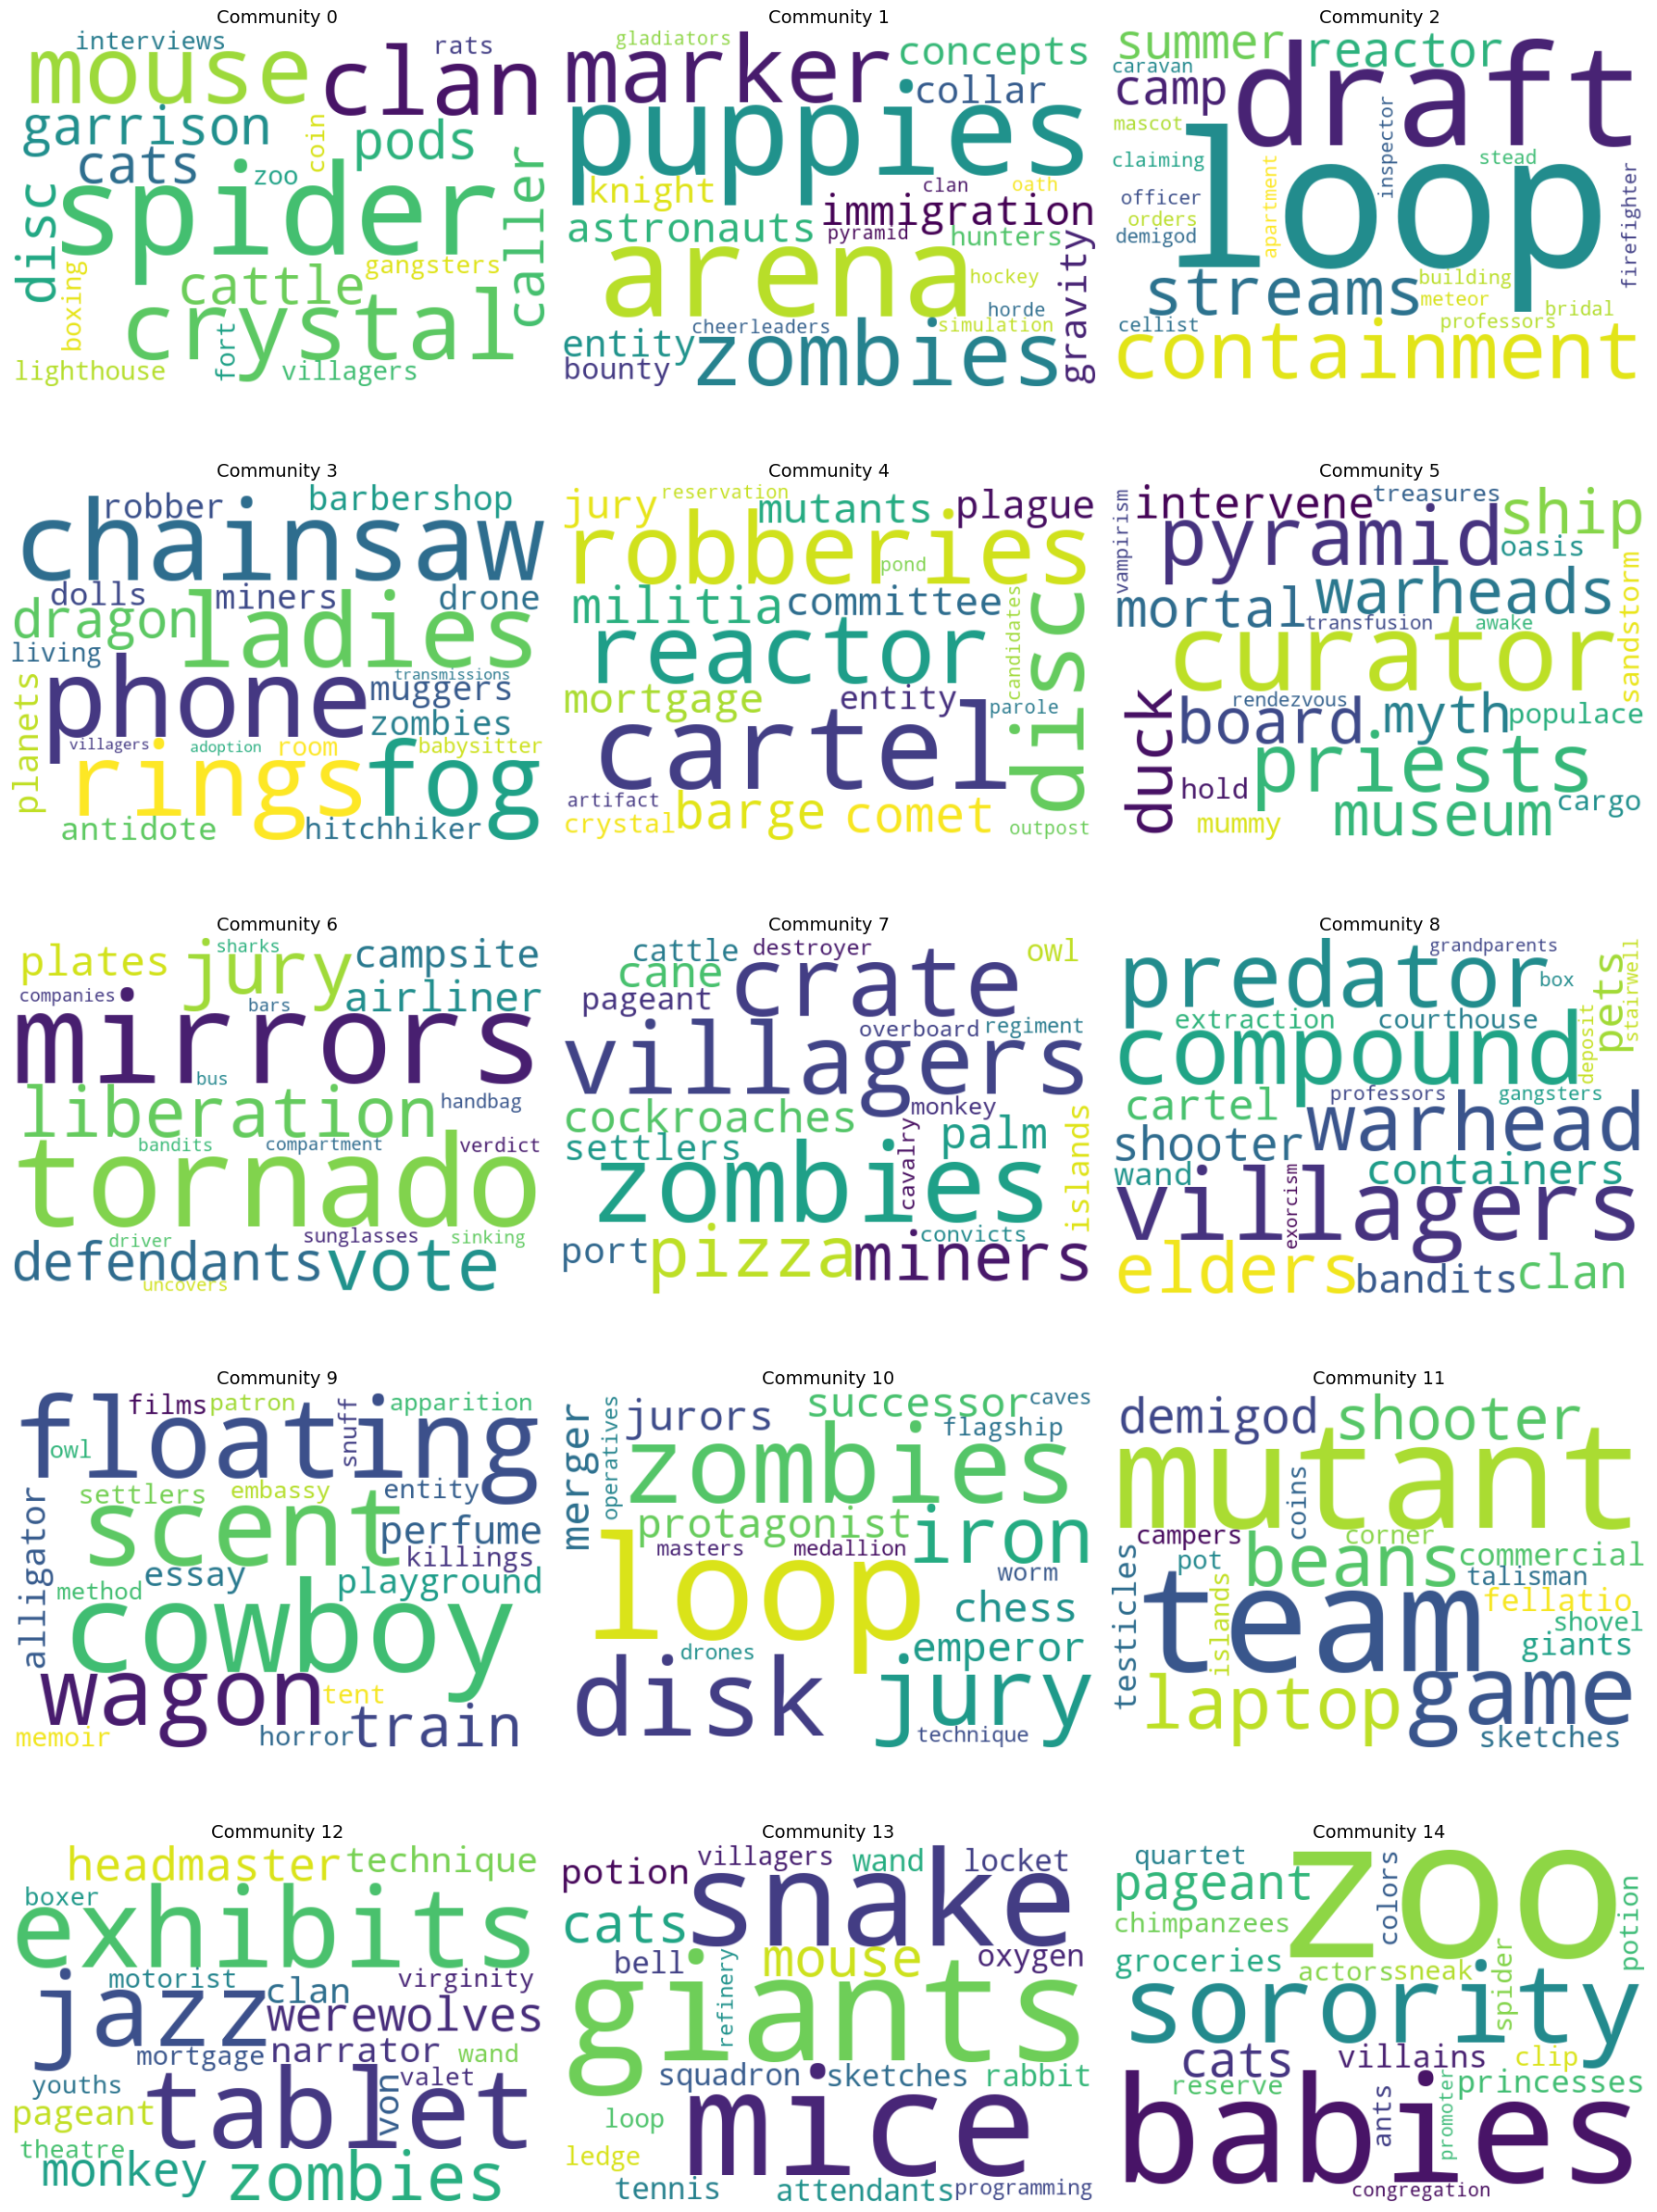

In [46]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import math

# List of community IDs sorted (so the layout is consistent)
community_ids = sorted(refined_top_terms.keys())

# Grid layout: 3 per row
cols = 3
rows = math.ceil(len(community_ids) / cols)

plt.figure(figsize=(18, 5 * rows))

for idx, comm_id in enumerate(community_ids, 1):
    # Combine terms into text
    text = " ".join(refined_top_terms[comm_id])

    # Generate word cloud
    wc = WordCloud(
        width=600,
        height=400,
        background_color="white",
        colormap="viridis"
    ).generate(text)

    # Subplot position
    plt.subplot(rows, cols, idx)
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Community {comm_id}", fontsize=14)

plt.tight_layout()
plt.show()


# 8. Community Profiles

With the backbone communities identified and all metadata attached (genres,
years, sentiment scores, TF–IDF themes, etc.), we can now describe what makes
each community unique. This section combines the different analyses performed
so far to form a complete profile of every backbone community.

For each community, we examine:
- its genre composition
- average sentiment based on VADER scores
- temporal structure (e.g., mean release year)
- dominant narrative themes from TF–IDF
- basic structural information such as size or notable directors

The goal is to understand not only how these communities form in the backbone
network, but also what kinds of movies and creative styles they represent.


## 8.1 Genre Composition

To understand what each backbone community represents, we begin by examining the
genres of the movies made by its directors. Using only the directors in the
backbone giant component, we count how many movies fall into each genre for each
community.

This gives a clear first impression of the creative identity of each group.
Some communities show strong specialization — for example, clusters dominated by
action, horror, or animation — while others mix several genres. These patterns
also help validate that the backbone communities are meaningful, since directors
who frequently collaborate often work within similar genre spaces.



In [47]:
# ============================================================
# 8.1 GENRE COMPOSITION (BACKBONE VERSION)
# ============================================================

from collections import Counter
import pandas as pd

def movies_of_community_backbone(comm_id):
    """Return movies directed by directors in the backbone GCC for this community."""
    movies = []
    for d in G_directors_gcc.nodes():                 # backbone directors only
        if partition_bb[d] == comm_id:               # backbone community assignment
            for m in T.neighbors(d):
                if T.nodes[m].get("bipartite") == "movie":
                    movies.append(m)
    return movies

community_genre_counts_bb = {}

# Use backbone communities only
for comm_id in sorted(set(partition_bb.values())):
    movies = movies_of_community_backbone(comm_id)
    genres = []

    for m in movies:
        g_list = T.nodes[m].get("genres")
        if isinstance(g_list, list):
            genres.extend(g_list)

    community_genre_counts_bb[comm_id] = Counter(genres)

# Build dataframe
all_genres_bb = set()
for c in community_genre_counts_bb.values():
    all_genres_bb.update(c.keys())

genre_df_bb = pd.DataFrame(
    0,
    index=community_genre_counts_bb.keys(),
    columns=sorted(all_genres_bb)
)

for comm_id, counter in community_genre_counts_bb.items():
    for genre, count in counter.items():
        genre_df_bb.loc[comm_id, genre] = count

display(genre_df_bb)


,Action,Adventure,Animation,Biography,Comedy,Crime,Documentary,Drama,Family,Fantasy,...,Horror,Music,Musical,Mystery,Romance,Sci-Fi,Sport,Thriller,War,Western
0,129,93,15,53,125,102,2,300,26,30,...,36,15,11,53,69,29,14,71,11,20
1,41,30,0,1,17,14,0,15,4,11,...,11,3,2,2,5,15,1,9,1,0
2,19,6,1,0,48,10,0,15,1,9,...,0,0,0,1,11,4,4,4,2,0
3,143,65,6,10,98,89,0,85,6,20,...,72,5,2,28,19,27,1,85,3,1
4,135,79,9,53,97,128,2,292,12,35,...,24,13,3,39,54,39,14,85,13,3
5,13,10,1,0,3,2,0,20,1,11,...,9,1,0,5,1,5,2,1,0,0
6,84,54,5,17,48,58,0,131,8,11,...,34,4,2,50,39,20,4,77,14,7
7,45,42,2,9,77,21,0,91,10,11,...,19,3,4,14,52,13,5,19,11,14
8,145,74,4,19,54,88,0,172,5,14,...,38,3,3,34,42,39,9,94,7,12
9,13,7,0,6,50,28,0,84,1,8,...,38,3,3,32,19,11,0,34,2,6


## 8.2 Sentiment Patterns

To compare emotional tone across backbone communities, we assign each movie a
VADER compound sentiment score and compute the average score for the movies
directed within each community. Most values are slightly negative, which is
normal for plot summaries because they often contain conflict-driven or
emotionally charged wording. 

Even so, the communities show clear relative differences. Some clusters
(Community 2 and Community 3) lean toward more positive or neutral narratives,
while others (such as Communities 5, 7, 14, and 16) are associated with darker
stories, often connected to horror, thriller, or crime-heavy genres. These
patterns align well with the genre profiles from Section 8.1.


In [48]:
# ------------------------------------------------------------
# Ensure every movie has a 'sent_happiness' VADER score
# ------------------------------------------------------------
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
nltk.download("vader_lexicon", quiet=True)

sia = SentimentIntensityAnalyzer()

sent_added = 0
sent_missing = 0

for node, data in T.nodes(data=True):
    if data.get("bipartite") != "movie":
        continue

    plot = data.get("wiki_plot")

    if isinstance(plot, str) and plot.strip():
        score = sia.polarity_scores(plot)["compound"]
        T.nodes[node]["sent_happiness"] = float(score)
        sent_added += 1
    else:
        T.nodes[node]["sent_happiness"] = None
        sent_missing += 1

print("Movies with sentiment score:", sent_added)
print("Movies missing sentiment:", sent_missing)


# ------------------------------------------------------------
# 8.2 SENTIMENT PATTERNS (BACKBONE ONLY)
# ------------------------------------------------------------
community_sentiment = {}

for comm_id in sorted(set(partition_bb.values())):      # backbone communities only
    movies = movies_of_community_backbone(comm_id)      # backbone directors only
    scores = []

    for m in movies:
        s = T.nodes[m].get("sent_happiness", None)
        if isinstance(s, (int, float)) and -1.0 <= s <= 1.0:
            scores.append(float(s))

    community_sentiment[comm_id] = (
        float(sum(scores) / len(scores)) if len(scores) > 0 else None
    )

print("Sentiment scores per backbone community:")
for c, s in community_sentiment.items():
    print(f"Community {c}: {s}")


Movies with sentiment score: 5923
Movies missing sentiment: 476
Sentiment scores per backbone community:
Community 0: -0.4922202764976959
Community 1: -0.6775786885245901
Community 2: -0.3840454545454545
Community 3: -0.5986459363957597
Community 4: -0.568991
Community 5: -0.7059
Community 6: -0.6501396694214876
Community 7: -0.3721421965317919
Community 8: -0.657425974025974
Community 9: -0.7006883333333334
Community 10: -0.5134296428571429
Community 11: -0.5751471264367816
Community 12: -0.4676631299734748
Community 13: -0.3983954666666667
Community 14: 0.045943333333333336


### 8.3 Temporal Patterns

We also examine when each backbone community is most active by looking at the
release years of its movies. For each community, we compute summary statistics
(mean, median, min, max year) using only movies connected to directors in the
backbone GCC.

These temporal patterns help distinguish communities focused on older films
from those dominated by more modern productions. They also provide context for
the genre and sentiment trends observed earlier — for example, older communities
tend to include classic westerns or early horror, while newer clusters often
feature action-heavy or CGI-driven films.


In [49]:
# ============================================================
# 8.3 TEMPORAL PATTERNS — BACKBONE COMMUNITIES ONLY
# ============================================================

import numpy as np
import pandas as pd

community_years_bb = {}

for comm_id in sorted(set(partition_bb.values())):
    
    # movies made by backbone directors in this community
    movies = movies_of_community_backbone(comm_id)
    years = []

    for m in movies:
        yr = T.nodes[m].get("year")
        if yr is not None and pd.notna(yr):
            try:
                years.append(int(yr))
            except:
                pass

    if len(years) > 0:
        community_years_bb[comm_id] = {
            "mean_year": np.mean(years),
            "median_year": np.median(years),
            "min_year": np.min(years),
            "max_year": np.max(years),
            "count_movies": len(years)
        }
    else:
        community_years_bb[comm_id] = None

print("Temporal statistics per backbone community:")
display(pd.DataFrame.from_dict(community_years_bb, orient="index"))


Temporal statistics per backbone community:


,mean_year,median_year,min_year,max_year,count_movies
0,1999.709251,2003.0,1925,2025,454
1,1999.650794,2001.0,1961,2025,63
2,1996.000000,1998.0,1922,2024,57
3,2005.082474,2008.0,1928,2025,291
4,1999.000000,2000.0,1918,2025,426
5,1989.531250,1998.5,1931,2025,32
6,1989.277344,1999.0,1900,2025,256
7,1989.850000,1997.0,1930,2024,180
8,1997.071875,2002.0,1933,2025,320
9,2000.496454,2003.0,1909,2025,141


### 8.4 Narrative Themes (TF–IDF)

To complement the genre and sentiment results, we also examine the narrative
themes that appear inside each backbone community using TF–IDF. These keywords
highlight recurring settings, creatures, objects, and story elements that are
not captured by genre labels alone.

The TF–IDF themes, together with the word cloud visualisations from Section 7,
give a clear sense of what each community focuses on creatively. When combined
with genres and temporal patterns, they help form a complete picture of the
storytelling style inside each cluster.


### 8.5 Putting It All Together

We now combine the different signals for each backbone community to form a full
profile: genre composition, average sentiment, typical release years, and the
dominant TF–IDF themes. Together, these features describe the creative identity
of each cluster — whether it leans toward action-heavy storytelling, horror,
mythology, courtroom drama, animation, or more experimental narrative styles.

These combined profiles give a clear, interpretable summary of what each
community represents and form the basis for the overall interpretation in the
final report.


In [50]:
# ============================================================
# 8.5 COMBINED SUMMARY TABLE (BACKBONE COMMUNITIES ONLY)
# ============================================================

summary_rows = []

backbone_comms = sorted(refined_top_terms.keys())

for comm_id in backbone_comms:

    # genre summary (top 5)
    gcount = community_genre_counts_bb.get(comm_id, {})
    top_genres = ", ".join([g for g, _ in gcount.most_common(5)]) if gcount else None

    # tf-idf summary (top 5 terms)
    top_terms = ", ".join(refined_top_terms[comm_id][:5])

    # sentiment stats from backbone dict
    sent_stats = community_sentiment_bb.get(comm_id, {})
    sentiment = sent_stats.get("mean_sentiment")
    movies_with_sentiment = sent_stats.get("movies_with_sentiment", 0)

    # temporal stats
    temp = community_years_bb.get(comm_id, {})
    mean_year = temp.get("mean_year")
    movies_with_year = temp.get("count_movies", 0)

    summary_rows.append({
        "community": comm_id,
        "movies_with_year": movies_with_year,
        "mean_year": mean_year,
        "mean_sentiment": sentiment,
        "top_genres": top_genres,
        "top_tfidf": top_terms
    })

df_summary = pd.DataFrame(summary_rows).set_index("community")
display(df_summary)


,movies_with_year,mean_year,mean_sentiment,top_genres,top_tfidf
community,,,,,
0,454,1999.709251,-0.091959,"Drama, Action, Comedy, Crime, Adventure","mouse, crystal, clan, garrison, caller"
1,63,1999.650794,-0.139624,"Action, Adventure, Comedy, Drama, Sci-Fi","puppies, arena, marker, zombies, immigration"
2,57,1996.000000,-0.064659,"Comedy, Action, Drama, Romance, Crime","draft, containment, streams, reactor, loop"
3,291,2005.082474,-0.114963,"Action, Comedy, Crime, Thriller, Drama","chainsaw, phone rings, ladies, fog, dragon"
4,426,1999.000000,-0.109141,"Drama, Action, Crime, Comedy, Thriller","cartel, robberies, reactor, disc, barge"
5,32,1989.531250,-0.111992,"Drama, Action, Fantasy, Adventure, Horror","pyramid, priests, warheads, duck, board ship"
6,256,1989.277344,-0.127100,"Drama, Action, Thriller, Crime, Adventure","tornado, mirrors, jury, vote, liberation"
7,180,1989.850000,-0.077106,"Drama, Comedy, Romance, Action, Adventure","zombies, villagers, crate, pizza, miners"
8,320,1997.071875,-0.136241,"Drama, Action, Thriller, Crime, Adventure","villagers, compound, predator, warhead, elders"


## Sentiment Over Time in Backbone Communities

To see whether the emotional tone of movies has changed over time inside each  
backbone community, we link **movie year** with **VADER sentiment** and fit a  
separate regression line per community.

For each backbone community we:

- take movies linked to its directors in the backbone GCC  
- keep only realistic years (1920–2025) and non-extreme sentiment scores  
- plot individual movies as faint points and fit a **linear trend line**

The scatter points show that sentiment is quite noisy at the movie level, but  
the regression lines reveal the overall direction for each group. Most  
communities have **fairly flat or slightly negative trends**, meaning their  
average plot sentiment is stable or drifting mildly darker over time. A few  
communities show **weak positive slopes**, suggesting a shift toward somewhat  
more positive story tones in their recent movies.

Overall, there is **no strong universal trend** across the backbone, but the  
plot helps identify which creative clusters are becoming a bit lighter or  
darker in mood across the decades.


Valid sentiment-year pairs: 438
Skipping Community 1 (too few points: 5)
Skipping Community 2 (too few points: 10)
Skipping Community 5 (too few points: 4)
Skipping Community 9 (too few points: 12)
Skipping Community 11 (too few points: 12)
Skipping Community 14 (too few points: 14)


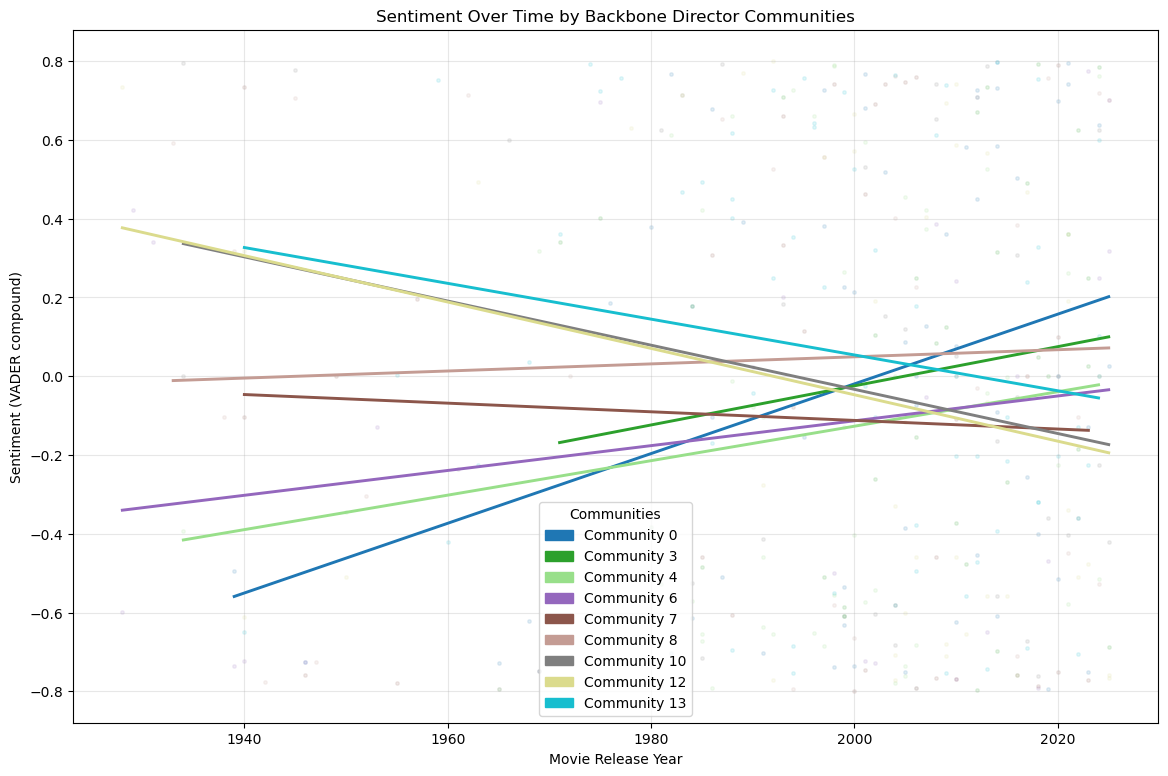

In [51]:
# ============================================================
# SENTIMENT OVER TIME PER BACKBONE COMMUNITY
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import matplotlib.patches as mpatches

# ------------------------------------------------------------
# Collect backbone communities
# ------------------------------------------------------------
target_comms = sorted(set(partition_bb[d] for d in G_directors_gcc.nodes()))
records = []

# ------------------------------------------------------------
# Assign consistent color map
# ------------------------------------------------------------
color_cycle = plt.cm.tab20(np.linspace(0, 1, len(target_comms)))
color_map = {comm: color_cycle[i] for i, comm in enumerate(target_comms)}

# ------------------------------------------------------------
# Build dataframe of year–sentiment pairs
# ------------------------------------------------------------
for comm in target_comms:
    
    directors = [d for d in G_directors_gcc.nodes() if partition_bb[d] == comm]

    movies = set()
    for d in directors:
        for nbr in T.neighbors(d):
            if T.nodes[nbr].get("bipartite") == "movie":
                movies.add(nbr)

    for m in movies:
        year = T.nodes[m].get("year")
        sentiment = T.nodes[m].get("sent_happiness")

        if year is None or sentiment is None:
            continue
        if np.isnan(year) or np.isnan(sentiment):
            continue
        if not (1920 <= year <= 2025):
            continue
        if sentiment < -0.8 or sentiment > 0.8:
            continue

        records.append({
            "community": comm,
            "year": int(year),
            "sentiment": sentiment
        })

df_time = pd.DataFrame(records)
print("Valid sentiment-year pairs:", len(df_time))

# ------------------------------------------------------------
# PLOTTING
# ------------------------------------------------------------
plt.figure(figsize=(14, 9))

# track which communities were plotted
plotted_comms = []

for comm in target_comms:

    subset = df_time[df_time["community"] == comm]

    # skip small communities
    if len(subset) < 20:
        print(f"Skipping Community {comm} (too few points: {len(subset)})")
        continue

    plotted_comms.append(comm)

    years = subset["year"].values
    sents = subset["sentiment"].values

    # scatter
    plt.scatter(years, sents, alpha=0.12, s=6, color=color_map[comm])

    # regression
    slope, intercept, r, p, stderr = linregress(years, sents)
    x_vals = np.linspace(years.min(), years.max(), 100)
    y_vals = intercept + slope * x_vals

    plt.plot(x_vals, y_vals, linewidth=2.1, color=color_map[comm])

# ------------------------------------------------------------
# LEGEND — Only plotted communities
# ------------------------------------------------------------
legend_patches = [
    mpatches.Patch(color=color_map[c], label=f"Community {c}")
    for c in plotted_comms
]

plt.legend(handles=legend_patches, title="Communities", fontsize=10)

# ------------------------------------------------------------
# Labels & Title
# ------------------------------------------------------------
plt.title("Sentiment Over Time by Backbone Director Communities")
plt.xlabel("Movie Release Year")
plt.ylabel("Sentiment (VADER compound)")
plt.grid(alpha=0.3)
plt.show()


### Sentiment Distribution Across Backbone Communities

To understand how emotional tone varies between director communities, we compute  
an **average VADER sentiment score for each director** (based only on movies that  
appear in the backbone network). This avoids noise from peripheral or weak ties  
and gives a clearer picture of sentiment inside the core collaboration structure.

We then group directors by Louvain community and visualise these distributions  
using a boxplot:

- **Each box = one community’s distribution of director-level sentiment**
- **The median line** shows the typical sentiment for that group
- **The box height** reflects how much variation exists between directors
- **No outliers are shown**, keeping the comparison clean

The plot highlights which communities tend toward darker emotional tone  
(e.g., horror- or crime-heavy clusters) and which lean slightly more positive  
(e.g., family-oriented or adventure-focused groups). Although most communities  
remain centered below zero — typical for VADER applied to plot summaries — the  
differences in spread and central tendency reveal meaningful stylistic contrasts  
across the backbone network.


Movies in backbone: 3188


/var/folders/l3/p66lfchd69v5dmm1fj5qmxp00000gn/T/ipykernel_47170/3179723708.py:91: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


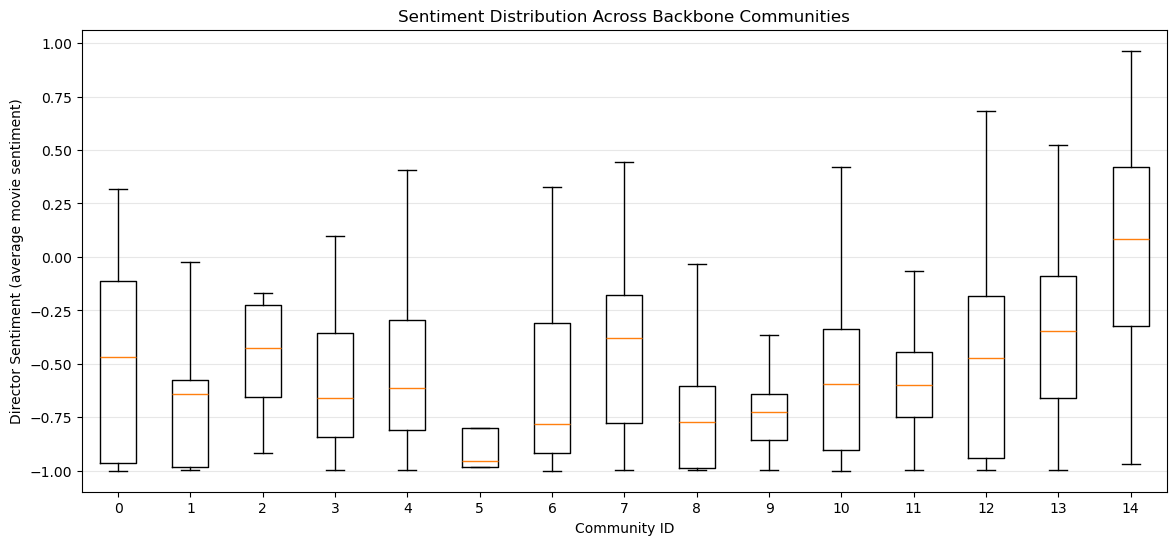

In [52]:
# ============================================================
#  SENTIMENT ANALYSIS FOR BACKBONE NETWORK ONLY 
# ============================================================

import matplotlib.pyplot as plt
import networkx as nx

# Make sure clean_plot_text exists
def clean_plot_text(text):
    if not isinstance(text, str):
        return None
    text = text.strip()
    if text.lower() in ["", "n/a", "none", "no plot", "unknown"]:
        return None
    if len(text.split()) < 20:
        return None
    return text

# ------------------------------------------------------------
# 1) Extract movies belonging to directors in the BACKBONE GCC
# ------------------------------------------------------------
backbone_movies = set()

for d in G_directors_gcc.nodes():
    for m in T.neighbors(d):
        if T.nodes[m].get("bipartite") == "movie":
            backbone_movies.add(m)

print("Movies in backbone:", len(backbone_movies))

# ------------------------------------------------------------
# 2) Compute SENTIMENT for BACKBONE movies only
# ------------------------------------------------------------
backbone_sentiment = {}

for m in backbone_movies:
    plot = T.nodes[m].get("wiki_plot")  # wiki plot text
    clean = clean_plot_text(plot)

    if clean:
        s = sia.polarity_scores(clean)["compound"]
    else:
        s = None

    backbone_sentiment[m] = s

# Store on movie nodes
nx.set_node_attributes(T, backbone_sentiment, "sent_backbone")

# ------------------------------------------------------------
# 3) Compute AVERAGE SENTIMENT PER DIRECTOR in the backbone
# ------------------------------------------------------------
director_sentiment = {}

for d in G_directors_gcc.nodes():
    scores = []
    for m in T.neighbors(d):
        if m in backbone_movies:
            s = T.nodes[m].get("sent_backbone")
            if s is not None:
                scores.append(s)

    director_sentiment[d] = sum(scores) / len(scores) if scores else None

nx.set_node_attributes(G_directors_gcc, director_sentiment, "sent_director")

# ------------------------------------------------------------
# 4) Aggregate sentiment PER COMMUNITY
# ------------------------------------------------------------
sent_by_comm = {}

for d in G_directors_gcc.nodes():
    comm = partition_bb[d]
    s = G_directors_gcc.nodes[d].get("sent_director")
    if s is not None:
        sent_by_comm.setdefault(comm, []).append(s)

# ------------------------------------------------------------
# 5) Create boxplot
# ------------------------------------------------------------
data = []
labels = []

for comm_id in sorted(sent_by_comm.keys()):
    vals = sent_by_comm[comm_id]
    if len(vals) > 0:
        data.append(vals)
        labels.append(str(comm_id))

plt.figure(figsize=(14, 6))
plt.boxplot(data, labels=labels, showfliers=False)
plt.title("Sentiment Distribution Across Backbone Communities")
plt.xlabel("Community ID")
plt.ylabel("Director Sentiment (average movie sentiment)")
plt.grid(axis='y', alpha=0.3)
plt.show()


# Appendix

## Code that created the graph

In [ ]:
# ============================================================
# BUILD TRIPARTITE GRAPH (Actors – Movies – Directors)
# ============================================================

import pandas as pd
import networkx as nx
import requests
from io import BytesIO

# Load dataset from GitHub
url = "https://raw.githubusercontent.com/jonhaukurb/Final-Project/refs/heads/main/imdb-movies-dataset.csv"
df = pd.read_csv(url)

# Clean fields
df["Title"] = df["Title"].astype(str).str.strip()
df["Director"] = df["Director"].fillna("").astype(str).str.strip()
df["Cast"] = df["Cast"].fillna("").astype(str)

# Split actor lists
df["Actors"] = df["Cast"].apply(lambda x: [a.strip() for a in x.split(",") if a.strip()])

# Initialize graph
T = nx.Graph()

# Add nodes + edges
for _, row in df.iterrows():
    movie = row["Title"]
    director_list = [d.strip() for d in row["Director"].split(",") if d.strip()]
    actors = row["Actors"]

    # Add movie node
    T.add_node(movie, bipartite="movie")

    # Add director nodes + edges
    for d in director_list:
        T.add_node(d, bipartite="director")
        T.add_edge(d, movie)

    # Add actor nodes + edges
    for a in actors:
        T.add_node(a, bipartite="actor")
        T.add_edge(a, movie)

print("Tripartite graph constructed!")
print("Nodes:", T.number_of_nodes())
print("Edges:", T.number_of_edges())

actor_count = sum(1 for _, d in T.nodes(data=True) if d.get("bipartite") == "actor")
director_count = sum(1 for _, d in T.nodes(data=True) if d.get("bipartite") == "director")
movie_count = sum(1 for _, d in T.nodes(data=True) if d.get("bipartite") == "movie")

print("Actors:", actor_count)
print("Directors:", director_count)
print("Movies:", movie_count)


## Code that scraped the Wikipedia plots

**Beware that it took about 4 hours to run**

In [53]:
import pandas as pd
import networkx as nx
from collections import Counter
import requests
import urllib.parse
import time
import re

url = "https://raw.githubusercontent.com/jonhaukurb/Final-Project/refs/heads/main/IMDB_tripartite_cleaned.graphml"

r = requests.get(url)
open("IMDB_tripartite_cleaned.graphml", "wb").write(r.content)


G = nx.read_graphml("IMDB_tripartite_cleaned.graphml")

movie_nodes = [n for n, data in G.nodes(data=True) if data.get("bipartite") == "movie"]

len(movie_nodes), movie_nodes[:10]

(6399,
 ['The Idea of You',
  'Kingdom of the Planet of the Apes',
  'The Fall Guy',
  'Challengers',
  'Abigail',
  'Civil War',
  'Twisters',
  'Anyone But You',
  'The Ministry of Ungentlemanly Warfare',
  'Dune: Part Two'])

In [54]:
orig_url = "https://raw.githubusercontent.com/jonhaukurb/Final-Project/refs/heads/main/imdb-movies-dataset.csv"
orig_df = pd.read_csv(orig_url)


orig_df_small = orig_df[["Title", "Year"]].drop_duplicates()

movies_df = pd.DataFrame({"Title": movie_nodes})

movies_df = movies_df.merge(orig_df_small, on="Title", how="left")

movies_df.head(10)

,Title,Year
0,The Idea of You,2023.0
1,Kingdom of the Planet of the Apes,2023.0
2,The Fall Guy,2023.0
3,Challengers,2023.0
4,Abigail,2023.0
5,Civil War,2023.0
6,Twisters,2023.0
7,Twisters,2014.0
8,Anyone But You,2023.0
9,The Ministry of Ungentlemanly Warfare,2023.0


### Set up Wikipedia helpers to find film pages and extract plots

In this block we prepare all the helper functions needed to query Wikipedia for each movie:

#### API session & cleaning utilities
We configure a requests session with a custom User-Agent and define small helpers like clean_year to safely convert noisy year values and normalize_title_words to clean titles and drop stopwords for matching.

#### Identifying the correct film page
First, we try some Wikipedia film title patterns such as
Title (YEAR film), Title (YEAR+1 film), Title (film), and just Title.
For each candidate, we:

Check that the page exists and is not a disambiguation page.

Fetch the REST summary and verify that it actually describes a film using a simple text heuristic (e.g., the summary mentioning “film” in the first sentence).

#### Search-based fallback
If no page works, we use the Wikipedia search API. We build multiple search queries (e.g. "Title 2001 film", "Title (2001 film)", "Title film"), then:

Compare word overlap between the movie title and candidate titles.

Prefer search results that mention “film” and (if available) the correct year.

Pick the best scoring film-like result.

#### Plot and year extraction

Once we have a page title, we:

Download the raw wikitext and try to extract the Plot (or Synopsis / Story) section, cleaning out wiki markup, links, and templates.

Fetch the REST summary and parse out a likely release year from the text.

If no plot section is found, we fall back to using the summary as a short description.

The function get_movie_plot_and_year(title, year_hint) coordinates all of this: it finds the right film page, extracts its plot and release year, and returns them for later use in our analysis. A short sleep between calls helps us be polite to the Wikipedia API. The reason we want to extract the year from Wikipedia is becuase we realized in the original IMDB dataset from Kaggle, the release dates are not always correct.

In [ ]:
from pathlib import Path

WIKI_API = "https://en.wikipedia.org/w/api.php"

SESSION = requests.Session()
SESSION.headers.update({
    "User-Agent": "movie-network-project/1.0 (contact: s242761@dtu.dk)"
})

def clean_year(y):
    """Convert float-like year to int, or None."""
    try:
        if pd.isna(y):
            return None
        return int(float(y))
    except Exception:
        return None


# ---------- word helpers for matching ----------

STOPWORDS = {
    "the", "a", "an", "of", "and", "or", "in", "on", "at", "to",
    "for", "by", "with", "from", "as", "is", "are", "be", "this",
    "that", "these", "those"
}

def normalize_title_words(s):
    """Lowercase, strip HTML, keep alnum + spaces, split into non-stopword words."""
    if not isinstance(s, str):
        return []
    s = re.sub(r"<.*?>", "", s)
    s = s.lower()
    s = re.sub(r"[^a-z0-9 ]+", " ", s)
    return [w for w in s.split() if w and w not in STOPWORDS]


def summary_looks_like_film(summary: str) -> bool:
    """Heuristic: does the summary clearly describe a film?"""
    if not isinstance(summary, str):
        return False
    first = summary.split(".")[0].lower()
    # examples: "Secretary is a 2002 American erotic romantic drama film..."
    if " film" in first or "feature film" in first:
        return True
    return False


# ---------- search-based fallback ----------

def wiki_search_movie_title(title, year_hint=None):
    """
    Use Wikipedia search API to find a film page.
    Strongly prefers:
      - title word overlap
      - snippet/title mentioning 'film'
    """
    y = clean_year(year_hint)

    queries = []
    if y:
        queries += [
            f"{title} {y} film",
            f"{title} ({y} film)"
        ]
    queries += [f"{title} film", title]

    base_words = set(normalize_title_words(title))

    best_title = None
    best_score = -999

    for q in queries:
        params = {
            "action": "query",
            "list": "search",
            "srsearch": q,
            "format": "json",
            "srlimit": 10
        }
        r = SESSION.get(WIKI_API, params=params)
        if r.status_code != 200:
            continue

        results = r.json().get("query", {}).get("search", [])
        for res in results:
            t = res.get("title", "")
            s = res.get("snippet", "")

            t_low = t.lower()
            s_clean = re.sub(r"<.*?>", "", s).lower()

            cand_words = set(normalize_title_words(t))
            shared = len(base_words & cand_words)

            film_flag = ("film" in t_low) or (" film" in s_clean)

            score = 0

            # need at least some content word overlap
            if shared == 0:
                score -= 10
            else:
                score += shared * 4

            if film_flag:
                score += 6

            if y is not None and str(y) in s_clean:
                score += 2

            if score > best_score and film_flag:
                best_score = score
                best_title = t

    if best_title and best_score > 0:
        return best_title
    return None


# ---------- page selection using canonical patterns + film check ----------

def find_wiki_movie_page(title, year_hint=None):
    """
    Try canonical film title patterns first:
      Title (YEAR film)
      Title (YEAR+1 film)
      Title (film)
      Title
    Accept only if:
      - page exists
      - not a disambiguation page
      - summary clearly describes a film
    If all fail, fall back to search-based movie lookup.
    """
    candidates = []
    y = clean_year(year_hint)
    if y:
        candidates.append(f"{title} ({y} film)")
        candidates.append(f"{title} ({y+1} film)")
    candidates.append(f"{title} (film)")
    candidates.append(title)

    for cand in candidates:
        # 1) check if page exists
        params = {
            "action": "query",
            "titles": cand,
            "format": "json"
        }
        r = SESSION.get(WIKI_API, params=params)
        if r.status_code != 200:
            continue

        pages = r.json().get("query", {}).get("pages", {})
        pageid, page = next(iter(pages.items()))
        if pageid == "-1":
            continue  # no such page

        # 2) REST summary to reject disambig & non-film
        safe = urllib.parse.quote(cand.replace(" ", "_"))
        url = f"https://en.wikipedia.org/api/rest_v1/page/summary/{safe}"
        r2 = SESSION.get(url)
        if r2.status_code != 200:
            continue

        data = r2.json()
        if data.get("type") == "disambiguation":
            continue

        summary = data.get("extract", "")
        if summary_looks_like_film(summary):
            # use canonical title from summary if present
            return data.get("title", cand)

    # If none of the simple patterns gave us a film page, fall back to search
    return wiki_search_movie_title(title, year_hint)


# ---------- wikitext + plot extraction ----------

def get_wikitext(page_title):
    """Download raw wikitext for a given page title."""
    params = {
        "action": "query",
        "titles": page_title,
        "prop": "revisions",
        "rvprop": "content",
        "rvslots": "main",
        "format": "json"
    }
    r = SESSION.get(WIKI_API, params=params)
    if r.status_code != 200:
        return None

    pages = r.json().get("query", {}).get("pages", {})
    page = next(iter(pages.values()))
    revs = page.get("revisions")
    if not revs:
        return None

    rev0 = revs[0]
    slots = rev0.get("slots", {})
    main_slot = slots.get("main", {})

    text = (
        main_slot.get("*") or
        main_slot.get("content") or
        rev0.get("*") or
        rev0.get("content")
    )

    return text


def extract_plot_from_wikitext(text):
    """
    Grab the Plot/Synopsis/Premise/Story section from wikitext and clean it.
    """
    if not isinstance(text, str):
        return None

    pattern = r"^==\s*(Plot|Plot summary|Synopsis|Premise|Story|Storyline)\s*==\s*$"
    m = re.search(pattern, text, flags=re.IGNORECASE | re.MULTILINE)
    if not m:
        return None

    start = m.end()
    rest = text[start:]

    # next top-level section
    m2 = re.search(r"^==\s*[^=].*?==\s*$", rest, flags=re.MULTILINE)
    end = m2.start() if m2 else len(rest)
    section = rest[:end]

    # remove HTML comments
    section = re.sub(r"<!--.*?-->", "", section, flags=re.DOTALL)
    # remove templates {{...}}
    section = re.sub(r"\{\{.*?\}\}", "", section, flags=re.DOTALL)
    # replace [[link|text]] / [[link]] with text
    section = re.sub(r"\[\[(?:[^|\]]*\|)?([^\]]+)\]\]", r"\1", section)
    # external links [http://... text]
    section = re.sub(r"\[https?:[^\s\]]+\s+([^\]]+)\]", r"\1", section)
    # bold/italic markup
    section = re.sub(r"'{2,}", "", section)
    # collapse whitespace
    section = re.sub(r"\s+", " ", section).strip()

    return section or None


def wiki_page_summary(page_title):
    safe = urllib.parse.quote(page_title.replace(" ", "_"))
    url = f"https://en.wikipedia.org/api/rest_v1/page/summary/{safe}"
    r = SESSION.get(url)
    if r.status_code != 200:
        return None
    data = r.json()
    return data.get("extract")


def extract_year_from_text(text):
    if not isinstance(text, str):
        return None
    m = re.search(r"\b(19[0-9]{2}|20[0-9]{2})\b", text)
    if m:
        return int(m.group(1))
    return None


def get_movie_plot_and_year(title, year_hint=None, sleep=0.25):
    """
    High-level:
      - find a *film* page (avoid job pages like 'Secretary')
      - get wikitext and extract Plot section
      - use summary to extract release year
      - if no Plot, fall back to summary text
    """
    page_title = find_wiki_movie_page(title, year_hint)
    if not page_title:
        time.sleep(sleep)
        return None, None, None

    wikitext = get_wikitext(page_title)
    plot = extract_plot_from_wikitext(wikitext)

    summary = wiki_page_summary(page_title)
    wiki_year = extract_year_from_text(summary)

    if not plot and isinstance(summary, str):
        plot = summary

    time.sleep(sleep)
    return page_title, plot, wiki_year

### Quick test: verify Wikipedia extraction on a few sample films

Before running our full data collection, we test the Wikipedia extraction pipeline on a small set of known movies.
For each title–year pair, we call get_movie_plot_and_year, which attempts to:

Identify the correct Wikipedia film page.

Extract its plot section (or fallback to the summary).

Infer a release year from the page’s text.

We then print the resolved page title, the detected release year, and the first part of the extracted plot.
This sanity check helps ensure that our matching, parsing, and cleaning functions behave correctly before we scale up to thousands of movies.

In [ ]:
for name, year in [
    ("Secretary", 2002),
    ("The Idea of You", 2023),
    ("Picnic at Hanging Rock", 1975),
]:
    w_title, w_plot, w_year = get_movie_plot_and_year(name, year)
    print("MOVIE:", name)
    print("  PAGE:", w_title)
    print("  YEAR:", w_year)
    print("  PLOT PREVIEW:", (w_plot or "")[:300], "\n")

### Test extraction on the first 10 movies in the network

To further validate our pipeline, we run the Wikipedia extraction process on a small subset of the actual movie list — the first 10 titles from our dataset.

For each movie, we:

- Use the IMDB release year (if available) as a hint.

- Call get_movie_plot_and_year to retrieve:

- The matched Wikipedia page title

- The extracted plot text

- The inferred release year from Wikipedia

- Store these results in new columns.

Printing the mapping (e.g., original title → Wikipedia title) helps us verify that the matching logic is selecting the correct film pages.
The resulting DataFrame shows side-by-side comparisons of IMDB metadata and Wikipedia-derived information, giving us confidence before scaling up to the full dataset.

In [ ]:
test_df = movies_df.head(10).copy()

wiki_titles = []
wiki_plots  = []
wiki_years  = []

for _, row in test_df.iterrows():
    title = row["Title"]
    year_hint = row.get("Year", None)

    w_title, w_plot, w_year = get_movie_plot_and_year(title, year_hint)
    wiki_titles.append(w_title)
    wiki_plots.append(w_plot)
    wiki_years.append(w_year)

    print(f"{title}  →  {w_title}")

test_df["wiki_title"] = wiki_titles
test_df["wiki_plot"]  = wiki_plots
test_df["wiki_year"]  = wiki_years

test_df[["Title", "Year", "wiki_title", "wiki_year", "wiki_plot"]]

### Full-scale Wikipedia extraction for all movies

Now that the pipeline is tested, we run the Wikipedia extraction on all movies in our network.

For each movie in movies_df, we:

1. Use the IMDB year (when available) as a hint.

2. Call get_movie_plot_and_year with a small delay (SLEEP = 0.2) to avoid overloading the Wikipedia servers.

3. Collect:

- The matched Wikipedia page title

- The extracted plot text

- The inferred release year from Wikipedia

To make this long-running process safer and more transparent, we:

- Print progress every 100 movies (or at the very end), including:

-      How many movies have been processed so far

-      The current movie and its matched Wikipedia title

-      A short preview of the extracted plot


Save partial results to disk as movies_wiki_plots_partial.csv, so that progress is not lost if the run is interrupted.

When the loop finishes, we attach the collected wiki_title, wiki_plot, and wiki_year columns back to the full movies_df DataFrame, giving us a rich movie dataset augmented with Wikipedia-derived story information. This cell took about 3.5 hours to run and the output movies_wiki_plots_full.csv can be seen here: https://github.com/jonhaukurb/Final-Project/blob/main/movies_wiki_plots_full.csv.

In [ ]:
SLEEP = 0.2  # same as in get_movie_plot_and_year default, or adjust if you want

wiki_titles = []
wiki_plots  = []
wiki_years  = []

n = len(movies_df)
start = time.time()

for i, (_, row) in enumerate(movies_df.iterrows(), start=1):
    title = row["Title"]
    year_hint = row.get("Year", None)

    w_title, w_plot, w_year = get_movie_plot_and_year(title, year_hint, sleep=SLEEP)

    wiki_titles.append(w_title)
    wiki_plots.append(w_plot)
    wiki_years.append(w_year)

    # progress every 100 movies (you can change 100 to 50/200/etc)
    if i % 100 == 0 or i == n:
        elapsed_min = (time.time() - start) / 60
        print(f"[{i}/{n}]  {title}  →  {w_title}")
        if isinstance(w_plot, str):
            print("  Plot preview:", w_plot[:200].replace("\n", " "))
        else:
            print("  Plot preview: None")
        print(f"  Elapsed: {elapsed_min:.1f} minutes\n")

        # partial backup so you don't lose progress
        tmp = movies_df.iloc[:i].copy()
        tmp["wiki_title"] = wiki_titles
        tmp["wiki_plot"]  = wiki_plots
        tmp["wiki_year"]  = wiki_years
        tmp.to_csv("movies_wiki_plots_partial.csv", index=False)

# attach columns to full dataframe when done
movies_df["wiki_title"] = wiki_titles
movies_df["wiki_plot"]  = wiki_plots
movies_df["wiki_year"]  = wiki_years

### Now we save the complete dataset:

In [ ]:
movies_df["wiki_title"] = wiki_titles
movies_df["wiki_plot"]  = wiki_plots
movies_df["wiki_year"]  = wiki_years

# Save full output
movies_df.to_csv("movies_wiki_plots_full.csv", index=False)

print("Saved as movies_wiki_plots_full.csv")

### Load the final Wikipedia dataset for inspection

This dataset contains all movies from the network along with their matched Wikipedia titles, extracted plot summaries, and inferred release years.

Displaying the first few rows allows us to quickly confirm that the extraction pipeline worked as expected and that the data is ready for further analysis, such as text processing, topic modeling, or narrative similarity networks.

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/jonhaukurb/Final-Project/refs/heads/main/movies_wiki_plots_full.csv"
df = pd.read_csv(url)

df.head()